# Interpretations of the Saturnian Model for Electron Orbits
**Name:** Alex Kauffman

## Research Question

How do variations in the initial positions and velocities of an electron orbiting two nuclei in the Saturnian model influence the orientation of the orbit, and what thresholds define the transition from stability to instability?

## Starting Assumptions:

**Satunian Model**
- Since quantum mechanics wasn't yet developed in 1904, we’ll assume the electron’s behavior follows classical mechanics rather than quantum principles.
- This means we’ll treat the electron as a point particle with a well-defined position and velocity at any instant, and we won't account for effects like wave-particle duality or quantized energy levels.
- We will also assume that the electron does not radiate energy, as this is what the experiments at the time indicated, even though classical physics predicts that electrons radiate energy as they accelerate through an electric field

**Fixed Nucleus or Nuclei**
- To simplify the model, we’ll assume that both nuclei are fixed in space and do not move in response to the electron’s motion.
- This makes the simulation more straightforward, as we only need to calculate the motion of the electron and not the mutual attraction between multiple moving particles.

**Electrostatic Interactions Only**
- We'll assume the only force acting on the electron is the electrostatic force due to the positively charged nucleui
- This neglects other forces such as magnetic forces, which simplifies the calculation since Coulomb's law gives us a direct inverse-square law for the force.

**Two-Dimensional Motion**
- To make the system computationally easier to simulate and visualize, we could restrict the electron’s motion to two dimensions
- This assumption allows us to model the "rings" around the nucleus without needing to account for three-dimensional space.

## Defining a stable orbit:

Through the principle of energy conservation, we know that for any electron in a system with an initially negative energy, the electron will forever stay bound to the system. The reason for this is because the nuclei are fixed, and thus the only changing component is the electron. If the system's energy is initially negative, then the electron's must be initially negative, and thus the electron's final energy must also be negative to conserve energy. In fact, it's energy will be the same at all points in the orbit for this exact reason. The negative energy indicates that the electron has more potential energy (bound energy) than positive kinetic energy to escape the orbit. 

So our **definition of a stable orbit** will be any orbit in which the energy of the system is initially negative, and therefore, bound. Once the energy becomes positive, it must be that the electron has too much energy to be contained by the two nuclei and will escape.

The cell below defines a function that will be able to calculate the total energy of the system based on the conditions of the fixed charges, and the initial conditions of the the electron. The conditions of the charges simply relate to their spatial distance, but the electron's conditions include its spatial component and velocity components. The function takes these conditions, and calculates the energy of the system by summing the potential and kinetic energy of the system. As we previously defined, if this energy is negative we know we are in a bound state, and a stable orbit. We can use this code to see if a given set of initial conditons of an electron will provide us with a stable, or unstable orbit.

### Mathematical Explanation of Energy Calculations

#### Kinetic Energy

The **kinetic energy** $ K $ of the electron is calculated using:

$$K = \frac{1}{2} m (v_x^2 + v_y^2) $$
where $ v_x $ and $ v_y $ are the electron’s velocity components in the x- and y-directions, and m is the mass of the electron.

#### Potential Energy

The **potential energy** $ U $ of the electron in the field of each proton is calculated using Coulomb's law:

$$U = -\frac{k \cdot q_e \cdot q_p}{r} $$
The negative sign indicates that this is an **attractive potential**. The total potential energy $ U_e $ for the electron, considering both protons, is the sum of the individual potentials from each proton.

#### Total Energy

The **total energy** of the system is the sum of the electron’s kinetic and potential energy:

$$E = K + U $$
A **negative total energy** implies a **bound state** where the electron is confined to the vicinity of the protons. This is essential for determining stable orbits.

In [1]:
state0 = [8e-10, 2e-10, -191174.37861609043, 764697.5144643617]
fixed_charges = [[0, 0, 'r'], [0, 3e-10, 'r']]

# Function to calculate total energy of the system
def calculate_total_energy(state, fixed_charges):
    # Position of electron
    x_electron, y_electron = state[0], state[1]
    vx_electron, vy_electron = state[2], state[3]

    # Calculate potential energy due to each proton
    U_e = 0
    for charge in fixed_charges:
        r = np.sqrt((x_electron - charge[0])**2 + (y_electron - charge[1])**2)
        U_e += - (k * qe * qp) / r  # Negative potential energy for attractive force

    # Calculate kinetic energy
    K_e = 0.5 * m * (vx_electron**2 + vy_electron**2)

    # Total energy
    energy_system = U_e + K_e
    return energy_system

## Simulating an Electron Orbits in the Saturnian Model

The code in the cell block below will simulate the orbit of an electron around two fixed positively charged nuclei in the Saturnian model. This will allow us to investigate the orientation of different types of orbits in this model when e change the initial parameters of the electon. The code utilizes numerical integration to calculate the electron’s trajectory over time based on initial conditions and fixed charges. 

### Mathematical Breakdown of the Electron Orbit Simulation


The force acting on the electron from each fixed proton is calculated using **Coulomb’s law**, which describes the electrostatic force between two charged particles:

$$ F = \frac{k \cdot q_e \cdot q_p}{r^2} $$
where:
- $ k $ is Coulomb's constant $8.987 \times 10^9 $, $\text{N m}^2/\text{C}^2$,
- $ q_e $ is the charge of the electron $-1.602 \times 10^{-19} \, \text{C}$,
- $ q_p $ is the charge of the proton $1.602 \times 10^{-19} \, \text{C}$,
- $ r $ is the distance between the electron and the proton.

#### Direction of the Force

Since the force is attractive, we need to calculate its components in the **x- and y-directions** based on the relative positions of the electron and each proton. For a proton located at position $x_{\text{p}}, y_{\text{p}}$ and an electron at $(x, y)$, the distance $ r $ is:

$$r = \sqrt{(x - x_{\text{p}})^2 + (y - y_{\text{p}})^2} $$
The components of the force $ F_x $ and $ F_y $ are then given by:

$$F_x = -\frac{k \cdot q_e \cdot q_p}{r^3} \cdot (x - x_{\text{p}}) $$

$$F_y = -\frac{k \cdot q_e \cdot q_p}{r^3} \cdot (y - y_{\text{p}}) $$

The negative sign indicates that the force is attractive, pulling the electron toward the proton.

#### Calculating Acceleration

Using **Newton's second law** $ F = m \cdot a $, we find the acceleration components $ a_x $ and $ a_y $ by dividing the force components by the electron’s mass m :

$$ a_x = \frac{F_x}{m} $$

$$a_y = \frac{F_y}{m} $$

These accelerations are used in the differential equations for the electron’s motion.

#### Solving the Equations of Motion with `solve_ivp`

The `solve_ivp` function integrates the differential equations over time. For an electron with position $x, y$ and velocity $v_x, v_y$, the state vector $ \text{state} = [x, y, v_x, v_y] $ evolves according to:

$$\frac{dx}{dt} = v_x $$


$$\frac{dy}{dt} = v_y $$


$$ \frac{dv_x}{dt} = a_x $$

$$ \frac{dv_y}{dt} = a_y $$

where $ a_x $ and $ a_y $ are the accelerations computed from the Coulomb forces. The integration of these equations over time yields the trajectory of the electron.

#### Updating Position and Velocity Over Time

After setting up the differential equations for acceleration and velocity, the `solve_ivp` function integrates these equations over small time steps to update the electron's position and velocity iteratively. Here’s how this process works:

1. **Position Update**: At each time step  t , `solve_ivp` uses the differential equations to compute the instantaneous velocity components $ v_x $ and $ v_y $, which represent the rates of change of the position coordinates \( x \) and \( y \). The position is then updated as:
   
$$   x_{\text{new}} = x + \frac{dx}{dt} \cdot \Delta t = x + v_x \cdot \Delta t $$
   
$$   y_{\text{new}} = y + \frac{dy}{dt} \cdot \Delta t = y + v_y \cdot \Delta t $$

where $ \Delta t $ is the small time step size. This update gives the new position of the electron after each time step.

2. **Velocity Update**: Similarly, the acceleration components $ a_x $ and $ a_y $ are used to update the velocity components $ v_x $ and $ v_y $:

$$ v_{x_{\text{new}}} = v_x + \frac{dv_x}{dt} \cdot \Delta t = v_x + a_x \cdot \Delta t $$

$$   v_{y_{\text{new}}} = v_y + \frac{dv_y}{dt} \cdot \Delta t = v_y + a_y \cdot \Delta t $$

These updated velocities are used in the next time step to continue calculating the electron’s trajectory.

3. **Trajectory Calculation**: By applying a short time step ($d_t$), and repeating these updates iteratively over the specified time interval, `solve_ivp` produces a detailed trajectory of the electron as it moves under the influence of the electrostatic forces from the two nuclei. 

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def orbit_1(t, state):
    return state[1]  # Checks if y crosses 0
orbit_1.terminal = False
orbit_1.direction = 0  # Detects crossing in any direction

distance_threshold = 1e-10 # Proximity threshold for triggering events (e.g., 10 pm)

# Event function for proximity to nucleus 1
def near_nucleus1_event(t, state):
    x, y = state[0], state[1]
    distance = np.sqrt((x - fixed_charges[0][0])**2 + (y - fixed_charges[0][1])**2)
    return distance - distance_threshold  # Triggers when distance is below threshold
near_nucleus1_event.terminal = False
near_nucleus1_event.direction = 0  # Detect proximity in any direction

# Event function for proximity to nucleus 2
def near_nucleus2_event(t, state):
    x, y = state[0], state[1]
    distance = np.sqrt((x - fixed_charges[1][0])**2 + (y - fixed_charges[1][1])**2)
    return distance - distance_threshold  # Triggers when distance is below threshold
near_nucleus2_event.terminal = False
near_nucleus2_event.direction = 0  # Detect proximity in any direction

y_max = fixed_charges[1][1]
y_min = fixed_charges[0][1]

previous_x_left = None
# Event function for passing between the nuclei on the left side (x < 0 to x > 0)
def left_passage_between(t, state):
    global previous_x_left
    x, y = state[0], state[1]

    # Initialize previous_x_left on the first call
    if previous_x_left is None:
        previous_x_left = x

    # Check for a left-to-right crossing within the y-range
    if y_min < y < y_max and previous_x_left < 0 and x >= 0:
        previous_x_left = x  # Update previous_x_left to track the crossing
        return x  # Detect crossing but don't trigger orbit

    # Update previous_x_left without triggering
    previous_x_left = x
    return 1  # No trigger if conditions are not met

left_passage_between.terminal = False
left_passage_between.direction = 1  # Detect crossing from negative to positive x

def right_passage_between(t, state):
    x, y = state[0], state[1]
    # Define a tighter central region for passing detection
    x_threshold = 1e-11  # Small threshold for x around zero
    y_min, y_max = fixed_charges[0][1], fixed_charges[1][1]
    
    # Triggers when x > 0 to x < 0 and y is between the nuclei's y positions within a margin
    if -x_threshold < x < x_threshold and y_min < y < y_max:
        return x  # Trigger when x crosses zero within central region
    else:
        return 1  # No trigger if outside central region

right_passage_between.terminal = False
right_passage_between.direction = -1  # Detect crossing from positive to negative x


# Event function to detect if the electron goes below the threshold
def below_nucleus_threshold(t, state):
    y_threshold = -1e-10  # Adjust as needed based on the scale of orbits
    y = state[1]
    return y - y_threshold  # Triggers when y goes below the threshold

below_nucleus_threshold.terminal = False  # Stop the simulation if threshold is reached
below_nucleus_threshold.direction = 0   # Detect whenever crossed 

central_y_min = 0.14e-9
central_y_max = 0.15e-9
central_x_threshold = 5e-11  # Threshold for x-coordinate around zero

# Revised central gap detection event
def central_gap_event(t, state):
    x, y = state[0], state[1]
    
    # Only trigger if y is within central range and x is small enough
    if central_y_min < y < central_y_max:
        return abs(x) - central_x_threshold  # Positive inside, negative outside
    else:
        return 1  # Return a consistent positive value when not in the region

central_gap_event.terminal = False  # Do not terminate the simulation
central_gap_event.direction = 0     # Detect any direction of crossing

radial_variation_threshold = 0.6e-9  # Adjust as needed based on the simulation scale
initial_r = np.sqrt(state0[0]**2 + state0[1]**2)

def radial_variation_event(t, state):
    x, y = state[0], state[1]
    r = np.sqrt(x**2 + y**2)
    deviation = abs(r - initial_r)
    
    # Trigger event if the deviation from initial_r exceeds the threshold
    return deviation - radial_variation_threshold

# Thresholds for identifying an elliptical orbit
elliptical_variation_threshold = 1.0e-9  # Larger threshold for radial deviation
eccentricity_limit = 0.1  # Limit for eccentricity to classify as elliptical

# Initial radial distance
initial_r = np.sqrt(state0[0]**2 + state0[1]**2)

# Event function for detecting elliptical orbits
def elliptical_orbit_event(t, state):
    x, y = state[0], state[1]
    r = np.sqrt(x**2 + y**2)

    # Calculate eccentricity based on initial and current radius
    eccentricity = abs(r - initial_r) / (r + initial_r)

    # Check if both the radial deviation and eccentricity exceed their thresholds
    if abs(r - initial_r) > elliptical_variation_threshold and eccentricity > eccentricity_limit:
        return 0  # Trigger event if conditions for elliptical orbit are met

    return 1  # Return positive if conditions are not met

elliptical_orbit_event.terminal = False
elliptical_orbit_event.direction = 0  # Detect in any direction


# The physics
def diff_eqns(t, state):
    x, y, vx, vy = state
    
    fx, fy = 0, 0
    for charge in fixed_charges:
        r = np.sqrt((x - charge[0]) ** 2 + (y - charge[1]) ** 2)
        dir = -1.0  # Attractive force between electron and proton
        fx += dir * k * qe * qp / r**3 * (x - charge[0])
        fy += dir * k * qe * qp / r**3 * (y - charge[1])

    ax, ay = fx / m, fy / m
    return vx, vy, ax, ay

# Function to run the simulation
def run_sim3(state0):
    # Calculate and print the initial energy
    initial_energy = calculate_total_energy(state0, fixed_charges)

    # Times to be simulated
    t0, tmax, dt = 0, 2e-14, 1e-17  # seconds
    t_span = (t0, tmax)
    n_steps = int((tmax - t0) / dt + 1)
    times = np.linspace(t0, tmax, n_steps)
    
    # Call solve_ivp with very small tolerances for accuracy
    sol = solve_ivp(diff_eqns, t_span, state0, t_eval=times, rtol=1e-10, atol=1e-10, 
                    events=[orbit_1, near_nucleus1_event, near_nucleus2_event, left_passage_between, right_passage_between, below_nucleus_threshold, central_gap_event, radial_variation_event, elliptical_orbit_event])

    event_trigger = 0
    orbit_class = 0

    if sol.t_events[8].size > 1:
        event_trigger = 1
        orbit_class = 6 #Elliptical Orbit
    else:
        if sol.t_events[0].size == 0:
            event_trigger = 1
            orbit_class = 1 #Half Flower Orbit
        else:
                if sol.t_events[7].size == 0:
                    event_trigger = 1
                    orbit_class = 5 #Circular Orbit
                else:
                    if sol.t_events[5].size == 0 and sol.t_events[0].size > 0: 
                        event_trigger = 1
                        orbit_class = 3 #Balloon Orbit
                    else:
                        if sol.t_events[6].size == 0:
                            event_trigger = 1
                            orbit_class = 4 #Central Gap Flower

    if sol.t_events[1].size == 0 and sol.t_events[2].size == 0 and sol.t_events[3].size == 0 and sol.t_events[4].size > 0:
        event_trigger = 1
        orbit_class = 2 #Infinity Orbit

    if event_trigger == 0:
        orbit_class = 7 #Random Flower Orbit


    return initial_energy, sol, orbit_class


def plot_orbit(sol, fixed_charges):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(sol.y[0], sol.y[1], color='r')
    ax.grid(True)

    # Plot charges (nuclei)
    for charge in fixed_charges:
        ax.scatter(charge[0], charge[1], color=charge[2], s=100)

    # Set labels, limits, and show the plot
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_xlim([-2e-9, 2e-9])
    ax.set_ylim([-2e-9, 2e-9])

    plt.show()

Orbit 7 triggered: Random Flower
Energy of the System: -5.317011046991715e-19 J
The system is bound (negative total energy).


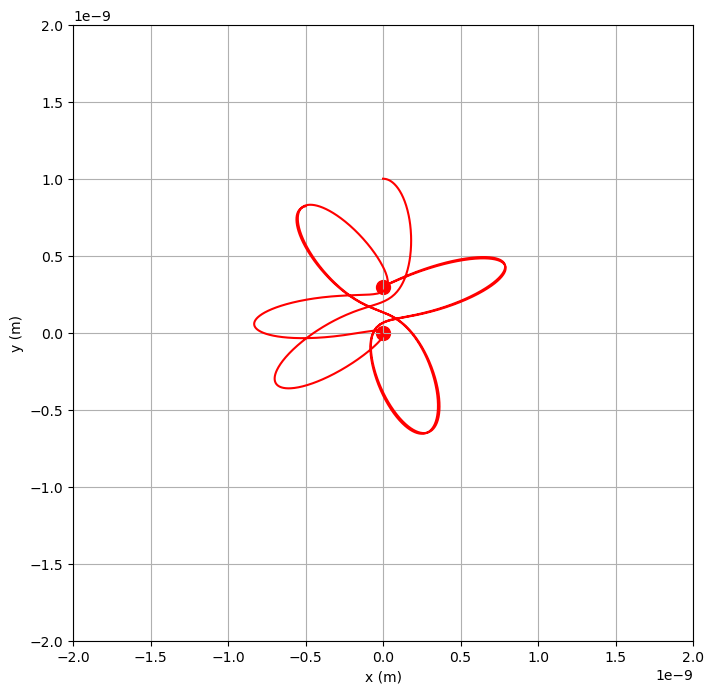

In [3]:
k = 8.9875517923e9  # Coulomb's constant; N*m^2/C^2
qe = 1.602e-19  # Charge of an electron in Coulombs
qp = 1.602e-19   # Charge of a proton in Coulombs
m = 9.109e-31    # Mass of an electron in kg

# Set up initial conditions
state0 = [0, 1e-9, 250000.0, 0]
fixed_charges = [[0, 0, 'r'], [0, 3e-10, 'r']]


energy, solution, orbit_class = run_sim3(state0)

if orbit_class == 1:
    print("Orbit 1 triggered: Restricted Flower")
elif orbit_class == 2:
    print("Orbit 2 triggered: Infinity Orbit")
elif orbit_class == 3:
    print("Orbit 3 triggered: Balloon Orbit")
elif orbit_class == 4:
    print("Orbit 4 triggered: Central Gap Flower")
elif orbit_class == 5:
    print("Orbit 5 triggered: Circular")
elif orbit_class == 6:
    print("Orbit 6 triggered: Elliptical")
elif orbit_class == 7:
    print("Orbit 7 triggered: Random Flower")

if energy < 0:
    print(f"Energy of the System: {energy} J")
    print("The system is bound (negative total energy).")
else:
    print("The system is unbound (positive total energy).")

# Plot the results
plot_orbit(solution, fixed_charges)

### Classification of Orbits

Through an investigation into the different orientation of orbits from looking at all possible initial velocities in a range of distances from the two nuclei, we were able to classify 7 distinct orbits:

#### Orbit 1: The Half Flower Orbit
This orbit is classified as an orbit in which the electron is unable to make it below the bottom nucleus because it experiences too much attraction to the top nucleus, and not enough velocity to escape that attraction

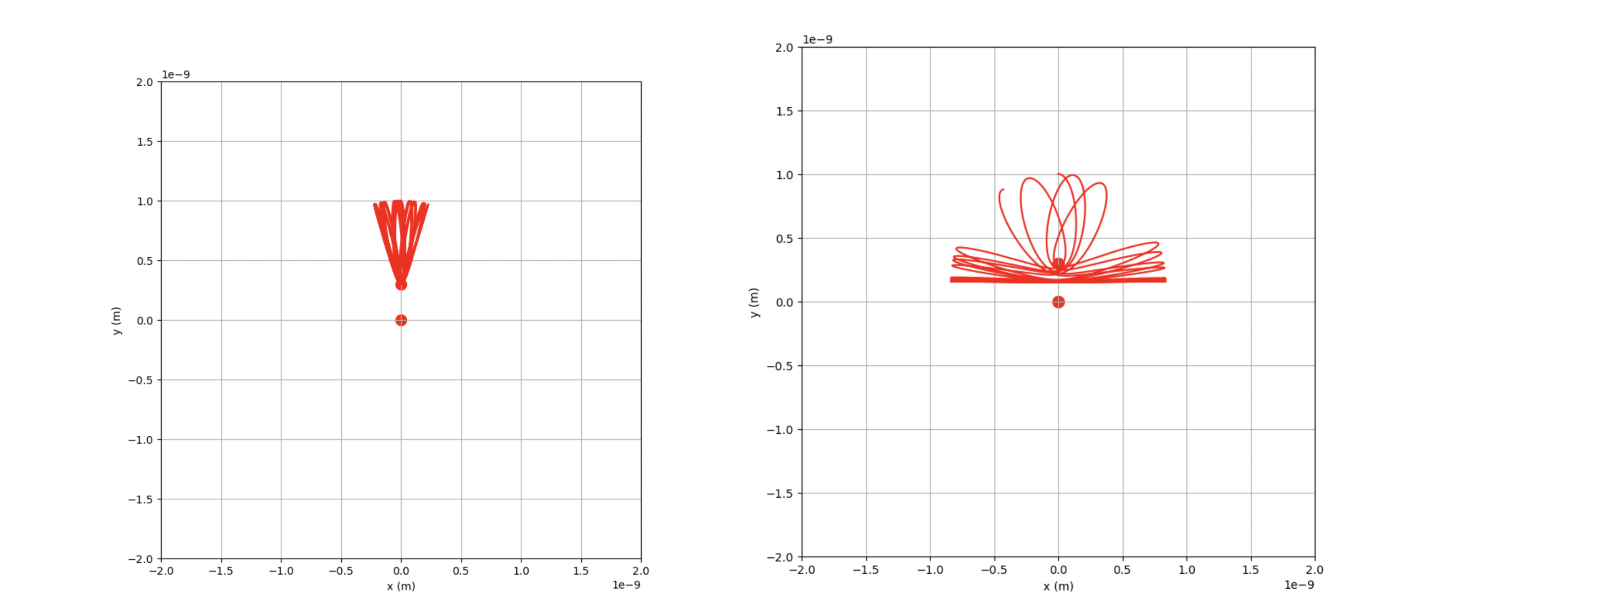


We can detect this orbit in the simulation by defining an event `orbit_1` which checks if the electron goes below the y coordinate of the bottom nucleus. If the event is not triggered, we know we are in a case of the "half flower orbit".


**Note:** We also must make sure that the elliptical orbit is triggered. If the elliptical orbit is triggered, then it means the half flower orbit will also be triggered. So we make sure that first the elliptical orbit is not triggered, and then see if the first orbit event was triggered or not

#### Orbit 2: The Infinity Orbit

The infinity orbit is defined as the orbit which resembles a figure-eight. It stems from the fact that the initital conditions are just right in which the two nuclei pull the electron into the middle of the orbit, and when the electron exits to one side, it experiences just the correct amount of restoring force to bring it back into the middle of the two nuclei once again. 

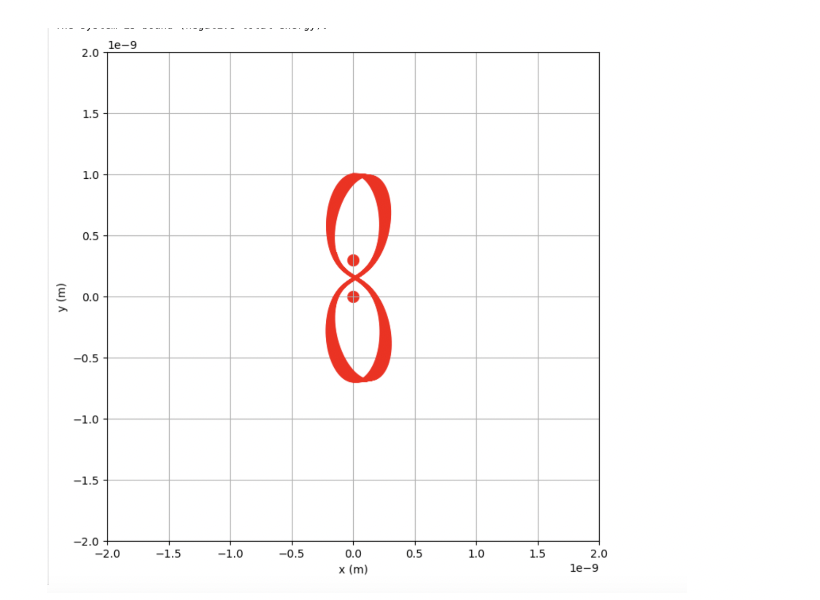

To detect this orbit, and differentiate it from just a random orbit, we need to define several specific events that must all be true, or not true to define the event as true:

- `near_nucelus1_event` and `near_nucelus2_event`checks to ensure that the electron does not get too close to either of the nuclei throughout its orbit. Since the electron must only pass in the middle of the two nuclei, we must make sure it never gets too close
- `left_passage_event` and `right_passage_event` are two events that work in unicent to make sure that the orbit of the electron is consistently only going through the gap between the two nuceli in one direction. Both events check if the electron goes through the gap between the two nuclei. Since in an infinity orbit, the electron is either constantly going through the gap from right to left, or from left to right, but not from both, we set the condition to see that one of these events is triggered, but not both

Through the definition of these events, we check to see if the near nuclei events are not triggered, and that one of the passage events is triggered. If these conditions are met, we know we are in an infinity orbit.


#### Orbit 3: The Balloon Orbit

This orbit is defined as an enveloping type of orbit, where the electron will orbit strictly on the right side of the two nuclei for a while, and then flip to orbit strictly on the left side, and flipping back and forth. This creates a balloon looking shape in the most pure of cases, and then can extend itself to a larger envelope where this orbit is still valid.

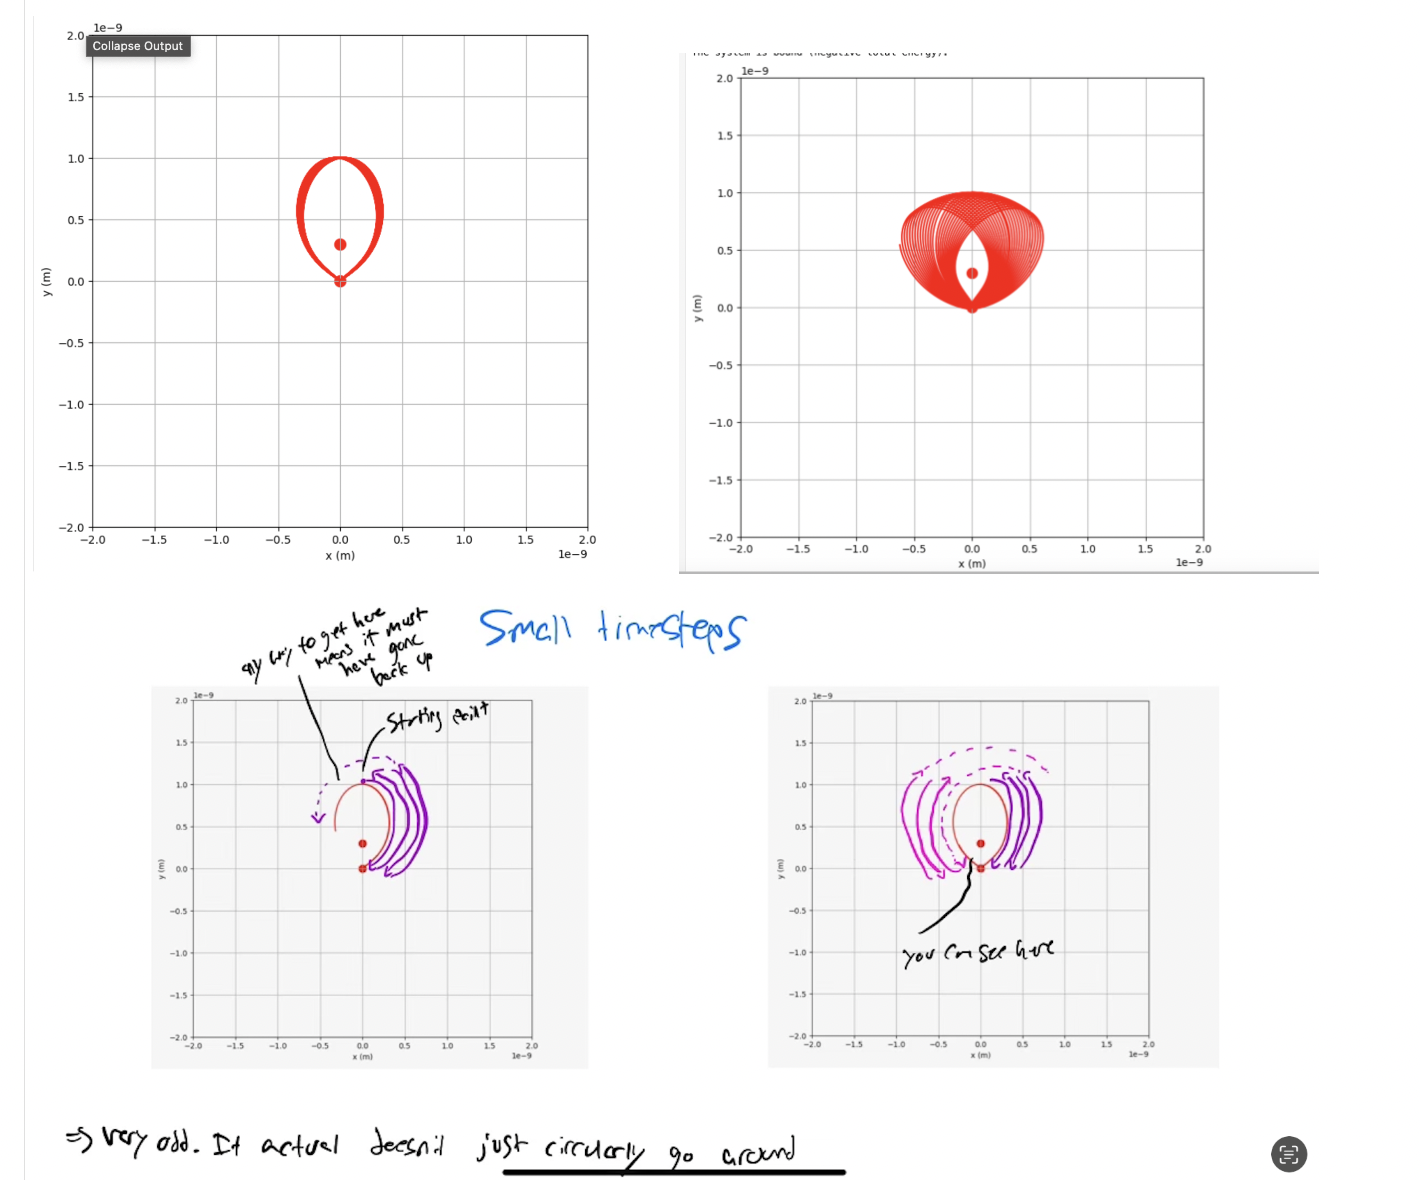
To detect this orbit, we create a new event called `below_nucleus_threshold`. This event checks to see if the orbit of the electron ever goes below a threshold distance the bottom nucleus. We must make sure that it does not go passed this threshold. If we use this event and the `orbit_1` event, we can properly detect the presence of this orbit. If we make sure that the below_nucleus_threshold event is not triggered, but ensure that the orbit_1 event is triggered (as to ensure it is not an orbit 1 type) then we have confirmed that this orbit is present.

**Note:** We must also make sure that orbits 1,5,6 are not triggered

#### Orbit 4: Central Gap Flower 

The central gap flower orbit is defined as a flower orbit in which there is a gap created in the trajectory of the electrons orbit. In the most pure of cases as seen in figure two below, this is essentially two repeating circular orbits


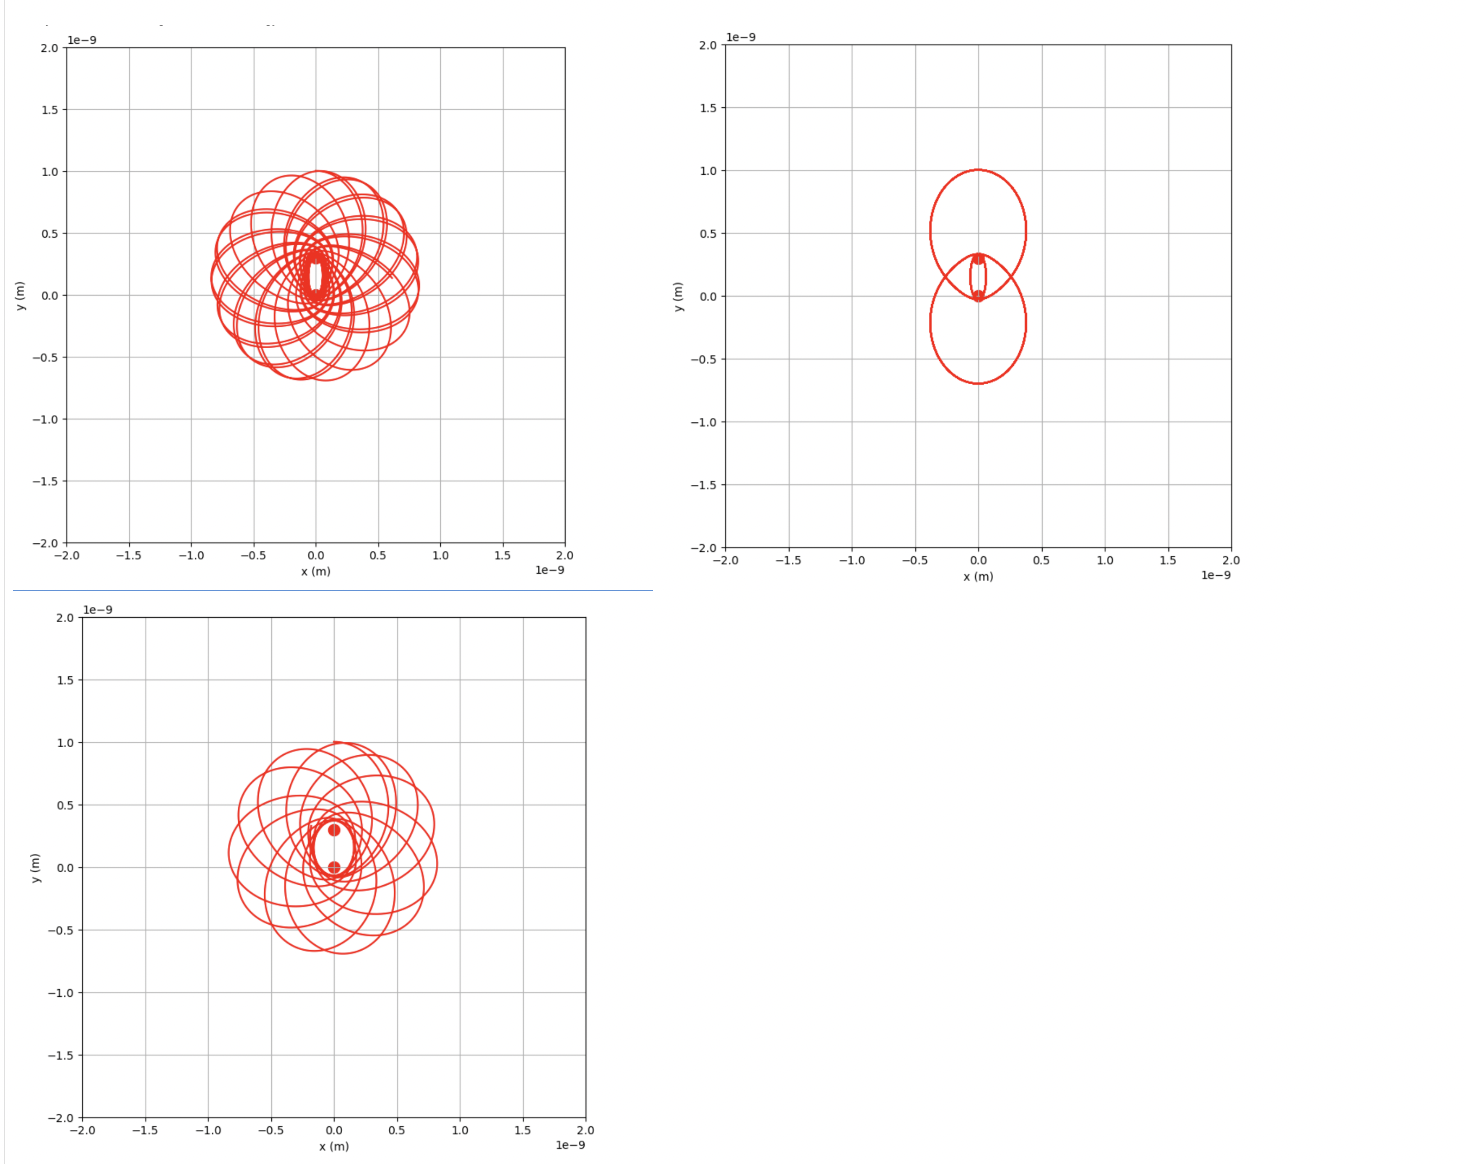
To detect this type of orbit, we create the event `central_gap_event`. This event checks to see if a gap was created by checking if the electron ever passes the midpoint of the two nuclei. It is also contingent on not being classified as any of the other types of orbits. If the central_gap_event is not triggered and the other orbits are not triggered, we know that this must be a central gap flower orbit

#### Orbit 5: Circular Orbits

Circular orbits are defined as orbits which have a circular trajectory around the two nuclei. 

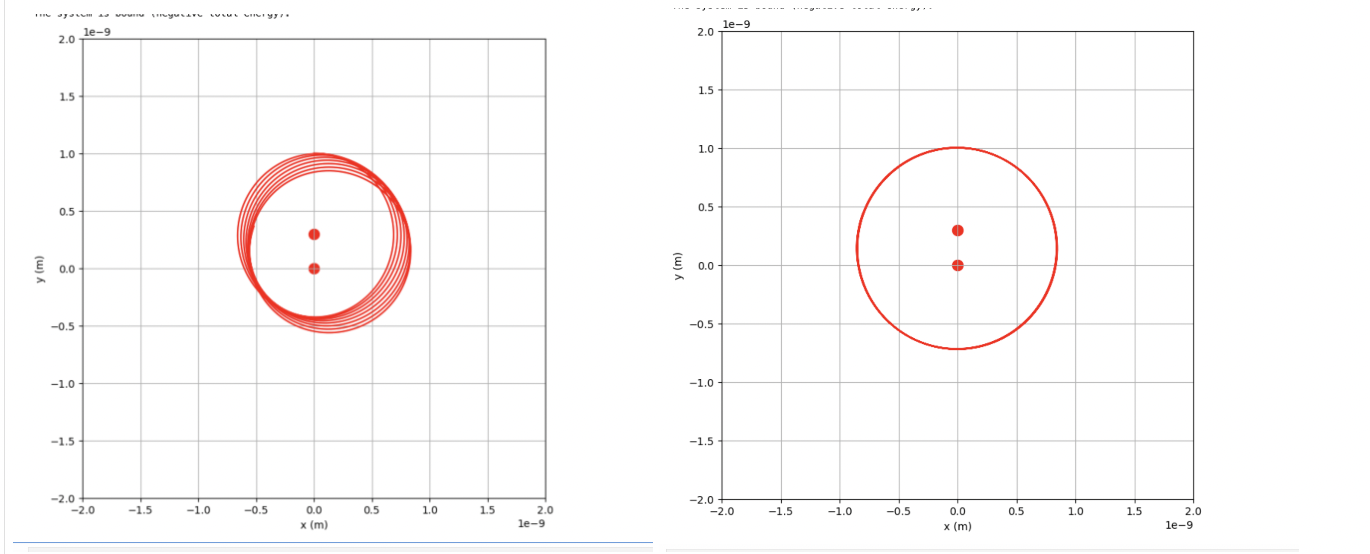

To detect this orbit we create the event `radial_threshold_event`. This event uses a threshold to make sure the distance from the midpoint of the two nuclei is constant. This will help diferentiate it from any type of flower orbit, because the orbit must stay constant in its radial distance from the midpoint of the two nuclei. If this event is not triggered, then we know we are in a circular orbit.

**Note:** We must also ensure orbits 1 and 6 are not triggered.

#### Orbit 6: Elliptical Orbits

Elliptical orbits are defined as stretched (elongated) orbits are the two nuclei. The elliptical orbits tend to lie on the edge of the threshold between stable and unstable orbits, which we will further investiage later in the paper.

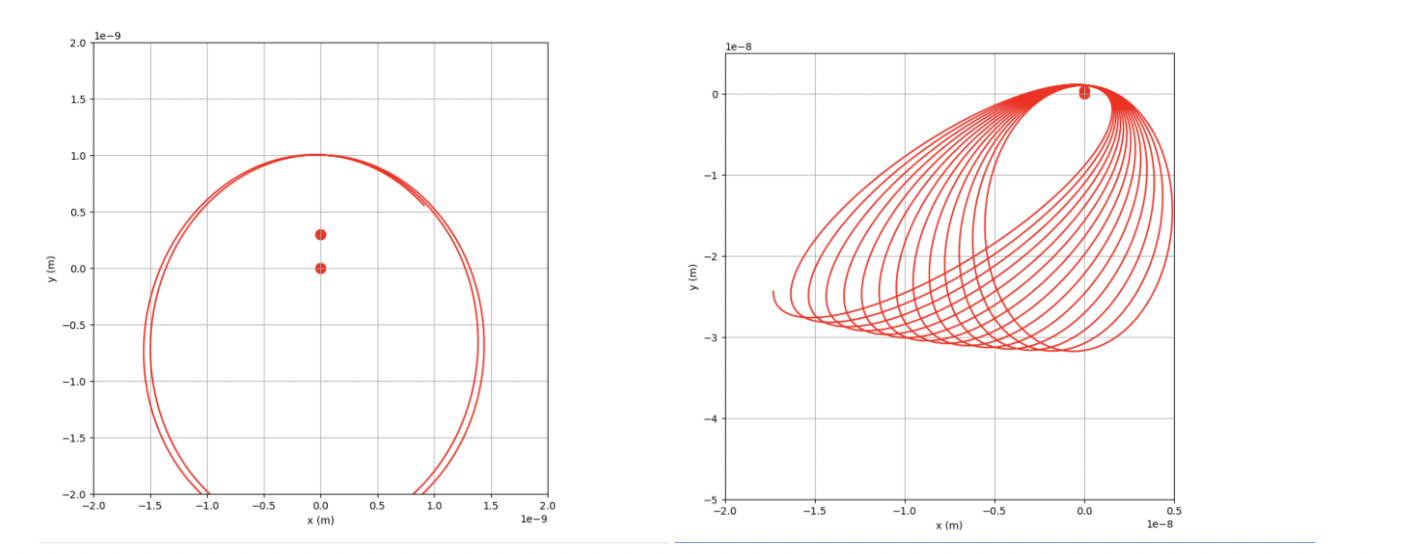

To detect this orbit we create the event `elliptical_orbit_event`. This event checks the eccentricity of the orbit. Circular orbits are prevalent at very small eccentricities. If the orbit has an eccentricity greater than 0.1, then the event will be triggered. Thus, if this event is triggered, we know we are in an elliptical orbit

#### Orbit 7: Random Flower Orbit

This orbit is defined as an orbit with no significant patterns to it. It is simply a random "flower" looking orbit with nothing identifying it as a special type of orbit. 

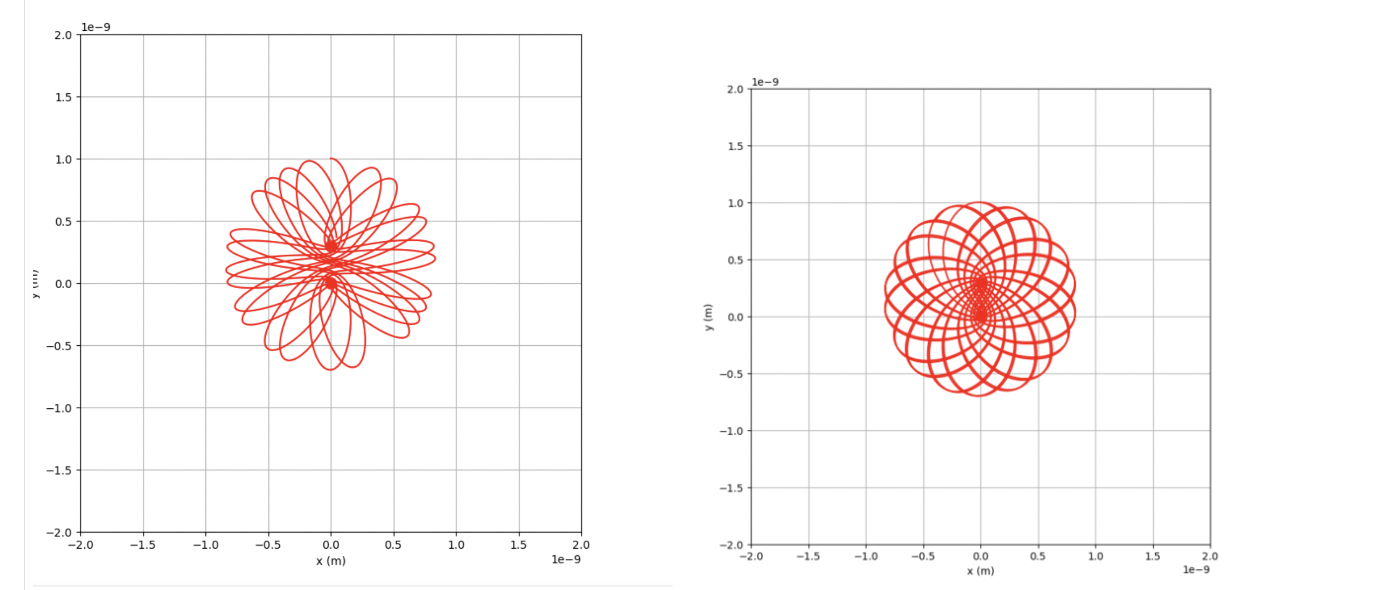

To detect this orbit we just make sure that it isn't any of the other specified orbits. The random flower orbit is essentially the base orbit where there are no identifying properties

## Investigating the Boundary of Stability vs Instability

- To investigate the characteristics of the bound vs unbound region, we will iterate code increasing the velocity until the electron becomes unbounded
- We can then extract information about its orbits around this boundary of velocity to find properties of this strip between stable and unstable orbits

We will use two plots to investigate the phase space of this region
1. Energy vs Initial Horiztonal Velocity Plot
- This plot will allow us to investigate the trend in increasing the velocity to the subsequent change in Energy, and see if there are any distinct changes in the boundary between stability and instability

2. Radius of Orbit vs Initial Horizontal Velocity Plot
- This plot will plot all types of orbits and their radii
- Through the phase space investigation, I noticed that the elliptical orbits close to the boundary of stability to unstability show interesting characteristics in regards to the orbital radius, and the subsequent orientation of their orbit
- Through plotting all the orbital radii with the changing velocity, we will be able to investigate any interesting changes when we get close to the region of instability

Energy becomes positive at 1110000.000


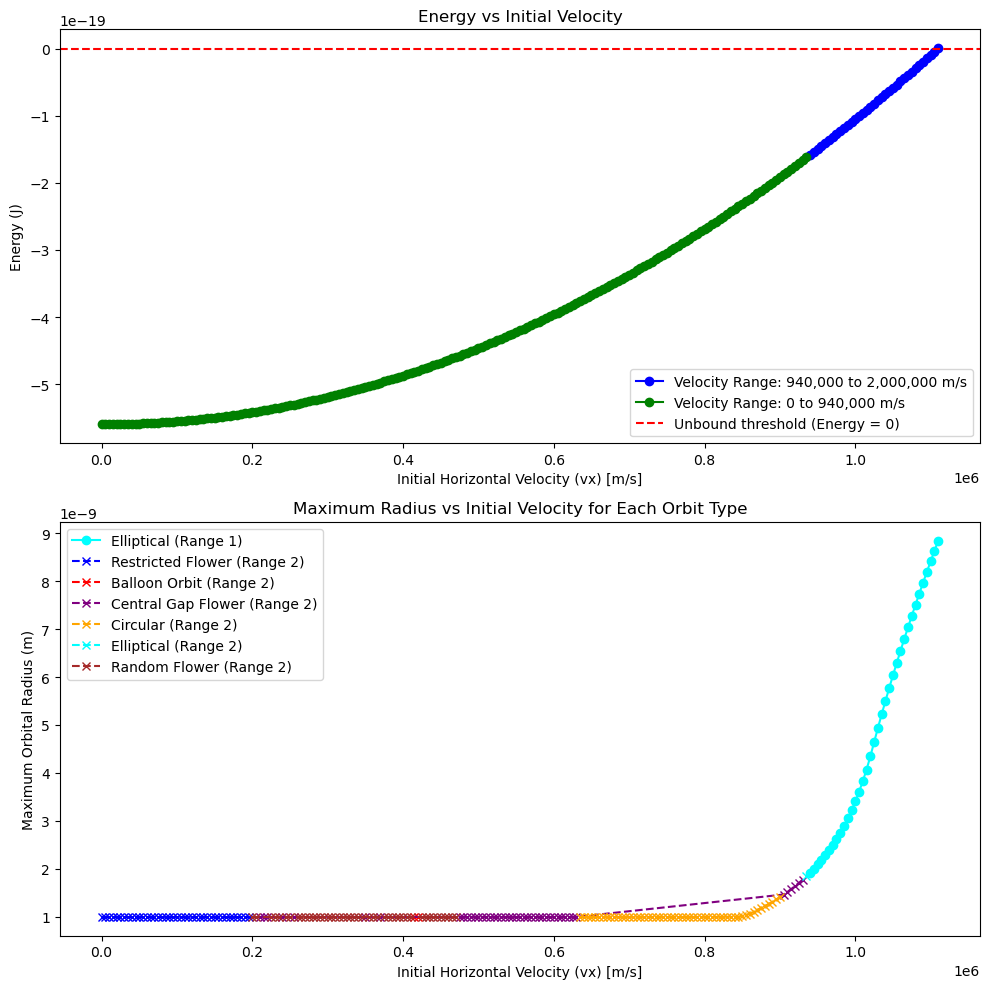

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Constants
k = 8.9875517923e9  # Coulomb's constant; N*m^2/C^2
qe = 1.602e-19  # Charge of an electron in Coulombs
qp = 1.602e-19   # Charge of a proton in Coulombs
m = 9.109e-31    # Mass of an electron in kg

# Fixed positions of charges (nuclei)
fixed_charges = [[0, 0, 'r'], [0, 3e-10, 'r']]

# Set initial conditions
state0 = [0, 1e-9, 940000.0, 0]  # Start with vx = 940000 m/s and increase

# Arrays to store results
velocities = []
energies = []
orbit_type_radii = {i: [] for i in range(1, 8)}  # Dictionary to store max radius for each orbit type

# Iterate over initial velocities for the first range
for vx in np.arange(940000, 2e6, 5000):  # Larger step of 5000 m/s to reduce computation
    state0[2] = vx  # Set the current initial velocity
    
    # Run the simulation and get energy and orbit class
    energy, solution, orbit_class = run_sim3(state0)
    
    # Calculate the maximum radius in the orbit
    max_radius = np.max(np.sqrt(solution.y[0]**2 + solution.y[1]**2))
    
    # Store results
    velocities.append(vx)
    energies.append(energy)
    orbit_type_radii[orbit_class].append((vx, max_radius))
    
    # Check if energy is positive (unbound system)
    if energy > 0:
        print(f"Energy becomes positive at {velocities[-1]:.3f}")
        break  # Stop iterating once the system becomes unbound

# Set up for the second range of velocities
state02 = [0, 1e-9, 0, 0]  # Reset initial x and y positions

# Arrays to store results for the second range
velocities2 = []
energies2 = []
orbit_type_radii2 = {i: [] for i in range(1, 8)}  # Dictionary to store max radius for each orbit type

# Iterate over initial velocities for the second range
for vx2 in np.arange(0, 940000, 5000):  # Reduced upper bound and larger step size
    state02[2] = vx2  # Set the current initial velocity
    
    # Run the simulation and get energy and orbit class
    energy2, solution2, orbit_class2 = run_sim3(state02)
    
    # Calculate the maximum radius in the orbit
    max_radius2 = np.max(np.sqrt(solution2.y[0]**2 + solution2.y[1]**2))
    
    # Store results
    velocities2.append(vx2)
    energies2.append(energy2)
    orbit_type_radii2[orbit_class2].append((vx2, max_radius2))

# Plot the results
plt.figure(figsize=(10, 10))

# Plot energy vs initial velocity
plt.subplot(2, 1, 1)
plt.plot(velocities, energies, marker='o', color='b', label="Velocity Range: 940,000 to 2,000,000 m/s")
plt.plot(velocities2, energies2, marker='o', color='g', label="Velocity Range: 0 to 940,000 m/s")
plt.axhline(0, color='r', linestyle='--', label="Unbound threshold (Energy = 0)")
plt.xlabel("Initial Horizontal Velocity (vx) [m/s]")
plt.ylabel("Energy (J)")
plt.title("Energy vs Initial Velocity")
plt.legend()

# Plot maximum radius vs initial velocity for each orbit type
plt.subplot(2, 1, 2)
orbit_colors = ['blue', 'green', 'red', 'purple', 'orange', 'cyan', 'brown']
orbit_labels = [
    "Restricted Flower", "Infinity Orbit", "Balloon Orbit", 
    "Central Gap Flower", "Circular", "Elliptical", "Random Flower"
]

# Plot for the first range
for orbit_type, color, label in zip(orbit_type_radii.keys(), orbit_colors, orbit_labels):
    if orbit_type_radii[orbit_type]:  # Only plot if there is data for this orbit type
        vx_values, radius_values = zip(*orbit_type_radii[orbit_type])
        plt.plot(vx_values, radius_values, marker='o', color=color, label=label + " (Range 1)")

# Plot for the second range
for orbit_type, color, label in zip(orbit_type_radii2.keys(), orbit_colors, orbit_labels):
    if orbit_type_radii2[orbit_type]:  # Only plot if there is data for this orbit type
        vx_values2, radius_values2 = zip(*orbit_type_radii2[orbit_type])
        plt.plot(vx_values2, radius_values2, marker='x', linestyle='dashed', color=color, label=label + " (Range 2)")

plt.xlabel("Initial Horizontal Velocity (vx) [m/s]")
plt.ylabel("Maximum Orbital Radius (m)")
plt.title("Maximum Radius vs Initial Velocity for Each Orbit Type")
plt.legend()
plt.tight_layout()
plt.show()



### Analyzing the Energy Radius vs Initial Horizontal Velocity Graphs

**Energy vs Initial Velocity Plot**
- The Energy vs Initial Velocity plot shows a fairly steady increase in velocity as we increase the horixontal velocity.
- The increase shows a fairly parabolic increase, which suggest that at higher velocities the energy will increase at a higher rate
- This is as expected as kinetic energy, which is based on velocity is proportional to $V^2$.
- We see that at an initial velocity of 110 000m/s the velocity is too high that the energy becomes positive and thus unbounded
- It is important to note that this velocity will change depending on where the electron's starting position is. A velocity of 110 000m/s does not necessarily correspond to an escape speed at all radii

**Maximum Radius vs. Initial Horizontal Velocity**
- The graph shows the interesting result where there essentially exists a turn-on point where after that velocity the plot shoots up
- The maximum radius of the elliptical orbit is increasing exponentially compared to the other types of orbits, until it reaches the threshold of 110 000m/s where the energy becomes positive and the electron is unbounded
- This is not what I would have intuitively thought to be the case, but it starts to make sense if you look at the calculation to calculate the attrcting force acting on the electron by the two nuceli
- The nuclei act on the electron with force proportion to $ 1 / \sqrt{r} $, so if the electron is able to escape the two nuclei initially due to its high velocity, it will be more dificult and take a longer distance 
- This graph resembles a graph of $ e^{nx}$, where n is some positive integer causing the graph to have a much more steep increase
- It is clear that all orbits that are not the elliptical orbit are present at lower velocities, but because of the higher velocities the grpah must be elliptical in nature
- This intuitively makes sense because initially the electron will not be able to be contained by the two nuclei, but it will eventually be pulled back by the two nuclei. This will intrinsically make the orbit eliptical because of the large ecentricity in nature because of the highter velocity

### Phase Space One: Iterating  Velocity
- We will firstly examine the changes in orbits due to a change in horizontal velocity 
- For simplicity, we will start at an initial position of x=0, and a vertical distance of $ 1.0^{-9}m $
- We can then get insight into the resulting types of orbits, and their frequency

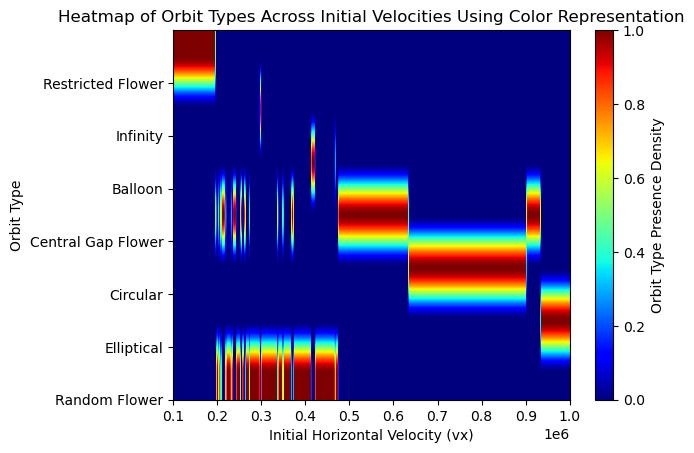

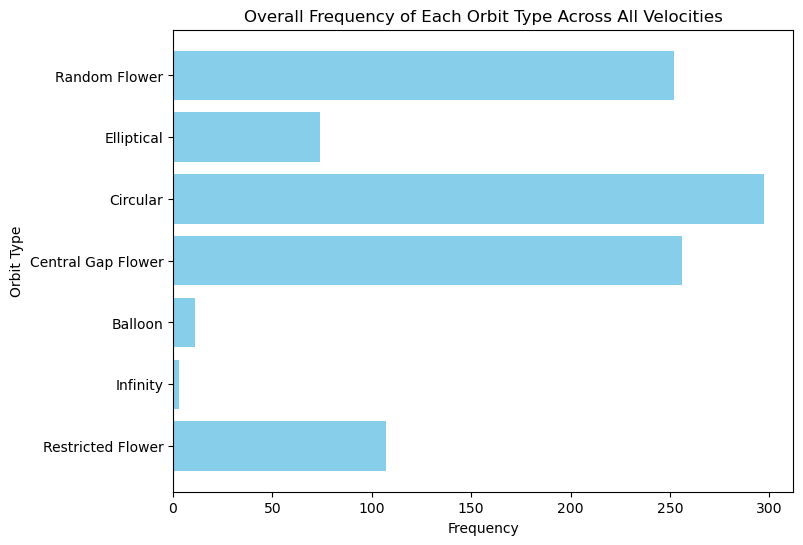

In [6]:
import numpy as np
import matplotlib.pyplot as plt


orbit_types = [
    "Random Flower",
    "Elliptical",
    "Circular",
    "Central Gap Flower",
    "Balloon",
    "Infinity",
    "Restricted Flower"
]

# Define the velocity and orbit type ranges
velocity_range = np.linspace(1e5, 1e6, 1000)  # Velocity range as before
orbit_type_indices = np.arange(len(orbit_types))  # Orbit type indices

# Create a 2D grid using meshgrid for plotting
vx2d, orbit2d = np.meshgrid(velocity_range, orbit_type_indices)

# Initialize a 2D array to hold the orbit classification values for each (vx, orbit type) pair
MH = np.zeros_like(vx2d)

# Run the simulation for each velocity and fill in the MH array based on orbit type classification
for i, velocity in enumerate(velocity_range):
    # Update initial conditions with the current velocity
    state0[2] = velocity
    energy, _, orbit_class = run_sim3(state0)  # Run simulation
    MH[orbit_class - 1, i] = 1  # Set MH to 1 for the detected orbit type at this velocity


# Plot the result using imshow with a 'jet' colormap
plt.imshow(MH, extent=(velocity_range[0], velocity_range[-1], 0, len(orbit_types)), cmap='jet', aspect='auto')
plt.colorbar(label="Orbit Type Presence Density")
plt.xlabel("Initial Horizontal Velocity (vx)")
plt.ylabel("Orbit Type")
plt.yticks(ticks=orbit_type_indices, labels=orbit_types)
plt.title("Heatmap of Orbit Types Across Initial Velocities Using Color Representation")
plt.show()

orbit_frequencies = MH.sum(axis=1)

# Plot the frequency of each orbit type as a bar plot with flipped data
plt.figure(figsize=(8, 6))
plt.barh(orbit_types, orbit_frequencies[::-1], color='skyblue')  # Only reverse orbit_frequencies, not orbit_types
plt.xlabel("Frequency")
plt.ylabel("Orbit Type")
plt.title("Overall Frequency of Each Orbit Type Across All Velocities")
plt.gca().invert_yaxis()
plt.show()

### Analysis of the Horizontal Velocity Iteration

**Heatmap Analysis (Initial Velocity vs. Orbit Type)**

The heatmap shows several horizontal bands where certain orbit types dominate specific ranges of initial velocities.
- For instance, "Random Flower" orbits appear primarily at lower initial velocities, while "Circular" and "Central Gap Flower" orbits dominate certain mid-range velocities.

Transition Regions:
- Aside from the distinct changes from one orbit to another, there is a region of instability with rapid changes between orbit types, in the range of $ 2 \times 10^5 m/s $ to $ 5 \times 10^5 m/s $
- This suggests that small changes in initial velocity in these regions can lead to different orbital behaviors.

- The "Random Flower" and "Circular" orbits have wider bands, suggesting that these are more stable or common for a broader range of initial velocities.
- Their prevalence indicates that they are likely stable under a variety of conditions, as they persist across larger velocity intervals.


**Frequency Bar Chart Analysis**

- "Random Flower", "Circular", and "Central Gap Flower" are the most common types of orbits, as shown by their high frequencies in the bar chart.
- This reinforces the observation from the heatmap that these orbits are stable across many velocities.

Less Common Orbits:
- "Balloon," "Infinity," and "Restricted Flower" orbits have relatively low frequencies.
- This suggests that these orbits require specific conditions and are less likely to occur under random initial velocities.
- These are fragile orbits, which require a lot of events to be true, and are thus why they are the least frequent orbits

**The transitions from one orbit to another are pretty smooth and there is not too variation from one orbit to another in a given region. This is because we are at a constant radius, and only changing the subsequent velocity, so the initial forces on the electron are always the same. However, if we change velocity, the transitions become less smooth, and thus we will iterate both position in the x and y direction below to get a better grasp at the different orbits as the electron is at different positiions in space.**

### Phase Space Two: Iterating Position

- We will now turn to iterating the x and y position of the initial position of the electron, while maintaining a constant velocity
- There is a constant velocity of $ 1 \times 10^5 $ because if the velocity was set to 0, no matter the position we would only get limited types of orbits. With an initial velocity we can get more types of orbits and therefore extract the conditions required to get a specific type of orbit given some position and some velocity

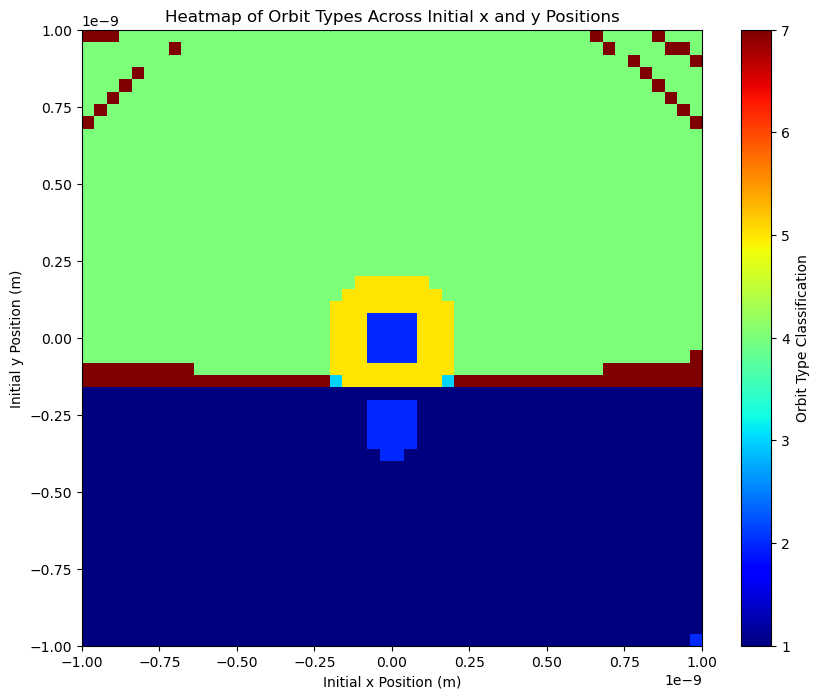

<Figure size 640x480 with 0 Axes>

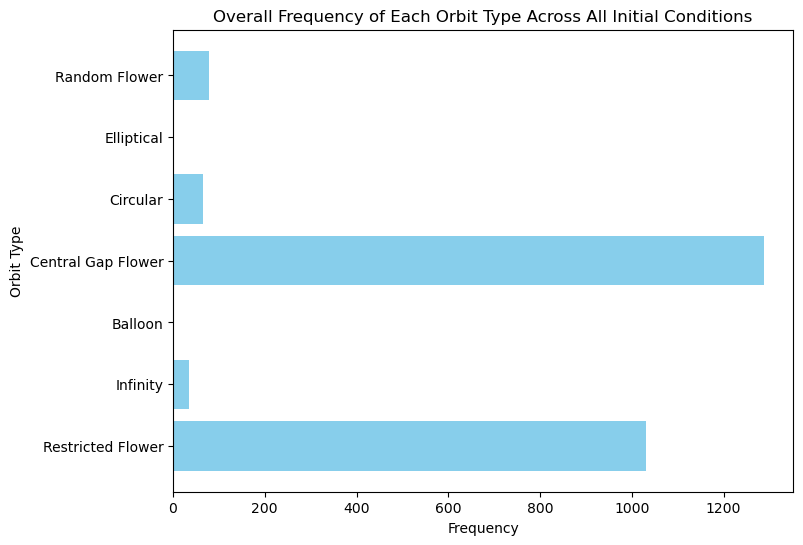

<Figure size 640x480 with 0 Axes>

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Define orbit types
orbit_types = [
    "Random Flower",
    "Elliptical",
    "Circular",
    "Central Gap Flower",
    "Balloon",
    "Infinity",
    "Restricted Flower"
]

# Define the range of x and y positions for initial coordinates
position_range_x = np.linspace(-1e-9, 1e-9, 50)  # Range for initial x-coordinate
position_range_y = np.linspace(-1e-9, 1e-9, 50)  # Range for initial y-coordinate

# Create a grid of initial positions
x2d, y2d = np.meshgrid(position_range_x, position_range_y)

# Initialize a 2D array to hold the orbit classification values for each (x, y) pair
MH = np.zeros((len(position_range_y), len(position_range_x)))

# Fixed initial velocity
state0 = [0, 0, 1e5, 0]  # Set an example initial velocity

# Run the simulation for each (x, y) combination and classify the orbit
for i in range(len(position_range_x)):
    for j in range(len(position_range_y)):
        # Set the initial x and y positions
        state0[0] = position_range_x[i]
        state0[1] = position_range_y[j]
        
        # Run the simulation and classify the orbit
        energy, _, orbit_class = run_sim3(state0)
        MH[j, i] = orbit_class  # Store orbit classification in the 2D grid

# Plot the heatmap with orbit classifications across the grid of initial positions
plt.figure(figsize=(10, 8))
plt.imshow(MH, extent=(position_range_x[0], position_range_x[-1], position_range_y[0], position_range_y[-1]), 
           cmap='jet', aspect='auto', interpolation='nearest')
plt.colorbar(label="Orbit Type Classification")
plt.xlabel("Initial x Position (m)")
plt.ylabel("Initial y Position (m)")
plt.title("Heatmap of Orbit Types Across Initial x and y Positions")
plt.show()

output_file = "position_iteration.png"
plt.savefig(output_file, format="png", dpi=300)  # Save as PNG with 300 DPI

orbit_frequencies = np.zeros(len(orbit_types))

# Count occurrences of each orbit type in the MH array
for orbit_class in range(1, len(orbit_types) + 1):
    orbit_frequencies[orbit_class - 1] = np.sum(MH == orbit_class)

# Plot the frequency of each orbit type as a bar plot with flipped data
plt.figure(figsize=(8, 6))
plt.barh(orbit_types, orbit_frequencies[::-1], color='skyblue')  # Only reverse orbit_frequencies, not orbit_types
plt.xlabel("Frequency")
plt.ylabel("Orbit Type")
plt.title("Overall Frequency of Each Orbit Type Across All Initial Conditions")
plt.gca().invert_yaxis()
plt.show()

output_file = "frequency_position.png"
plt.savefig(output_file, format="png", dpi=300)  # Save as PNG with 300 DPI

**Note, the orbit number in the first figure of the phase space corresponds to the frequency in the second plot**

### Analysis of the phase space

The phase space below gives very interesting results, much different than the velocity phase space

**Smoothness in transitions**
- The transitions in this phase space appear significantly less smooth compared to the earlier phase space analysis.
- There are numerous small inconsistencies scattered across the plot, which provide evidence of irregularities in the classifications.
- For example, there are two infinity orbit classifications close to the center of the orbit, both at a symmetric distance from eachother
- There are also these strips of the random flower classication at the top and right of the heat map
- These discrepancies suggest a lack of coherence in the transitions between different orbit types, which warrants further investigation.

**Symmetry in the heat map**
- There is a lot of symmetry in the plot, if one orbit occurs on one side of the system, it will most likely occur on the same side at the opposite corresponding x and y coordinate
- This is an interesting revelation, as the velocity is constant and moving to the right of the plot at all times, and thus is is not expected that the general orbits seen on the left side show so much similarity to that of the right side
- This is something we can investigate further, and see if the symmetry changes as we increase the constant velocity of the plot

**Differences in the position vs velocity phase space**
- Interestingly, the elliptical and balloon orbits do not show up in this phase space
- This differs from the velocity phase space, as the balloon orbit, all though not so frequent, did at least appear
- Similarly, the elliptical was very frequent in a sector of the velocity phase space
- *We can thus conclude that the elliptical orbit has a larger dependency on its velocity*
- This conclussion intuitively makes sense as the increase in velocity gives the orbit more eccentricity as it is difficult for the nuclei to pull the electron back towards them
- The circular orbit is also considerably less frequent then it was in the velocity phase space, pointing towards its dependence too on velocity, although this is not as intuitive of a result

**Similarities in the position vs velocity phase space**
- There are similarities in the frequencies of the central gap flower orbit, restricted flower orbit, and infinity orbit
- The central gap flower and restricted flower are the most frequent orbits in this phase space, which was also the case in the velocity phase space
- *This suggests that these two orbits are the most common orbits in the saturnian model*
- The inifinity orbit is very infrequent, although it does appear which is similar to its heat map in the velocity iteration
- We can conclude that the infinity orbit is a very fragile type of orbit, and is hard to achieve in a given orbital system
- This too, is expected, since there are a lot of events that define this type of orbit, and thus will be infrequent
- The balloon orbit, although not similar to the velocity system, is also a delicate orbit, because it has a lot of events that define it, and is hard to achieve.

**The position heat map and frequency bar graph help define conditions required for specific orbits. However, to further refine this understanding, we will explore the inconsistencies in this phase space, and see if any systematic trends are present in them, if these are mis-classifications by inconsistencies in the program, or perhaps they are just one off initial conditions that cause this orbit:**

### Investigating the Random Flower Instability Strips:

- There appears to be two strips of choppy transition from the central gap flower to the restricted flower, that move in a horizontal strip in both the top left and right.
- We will investigate these orbits more, and explore the general trends in an effort to learn more about the orbits
- The first thing we will do it zoom into the region, and plot another heat map to see if this trend continues outside the bouns of the above plot or if it ends
- We will also increase the velocity of the electron in these zoomed in regions, to see if the symmetry changes as we increase, or perhaps decrease the constant velocity, to give more insight into symmetries in orbits based on position and velocity

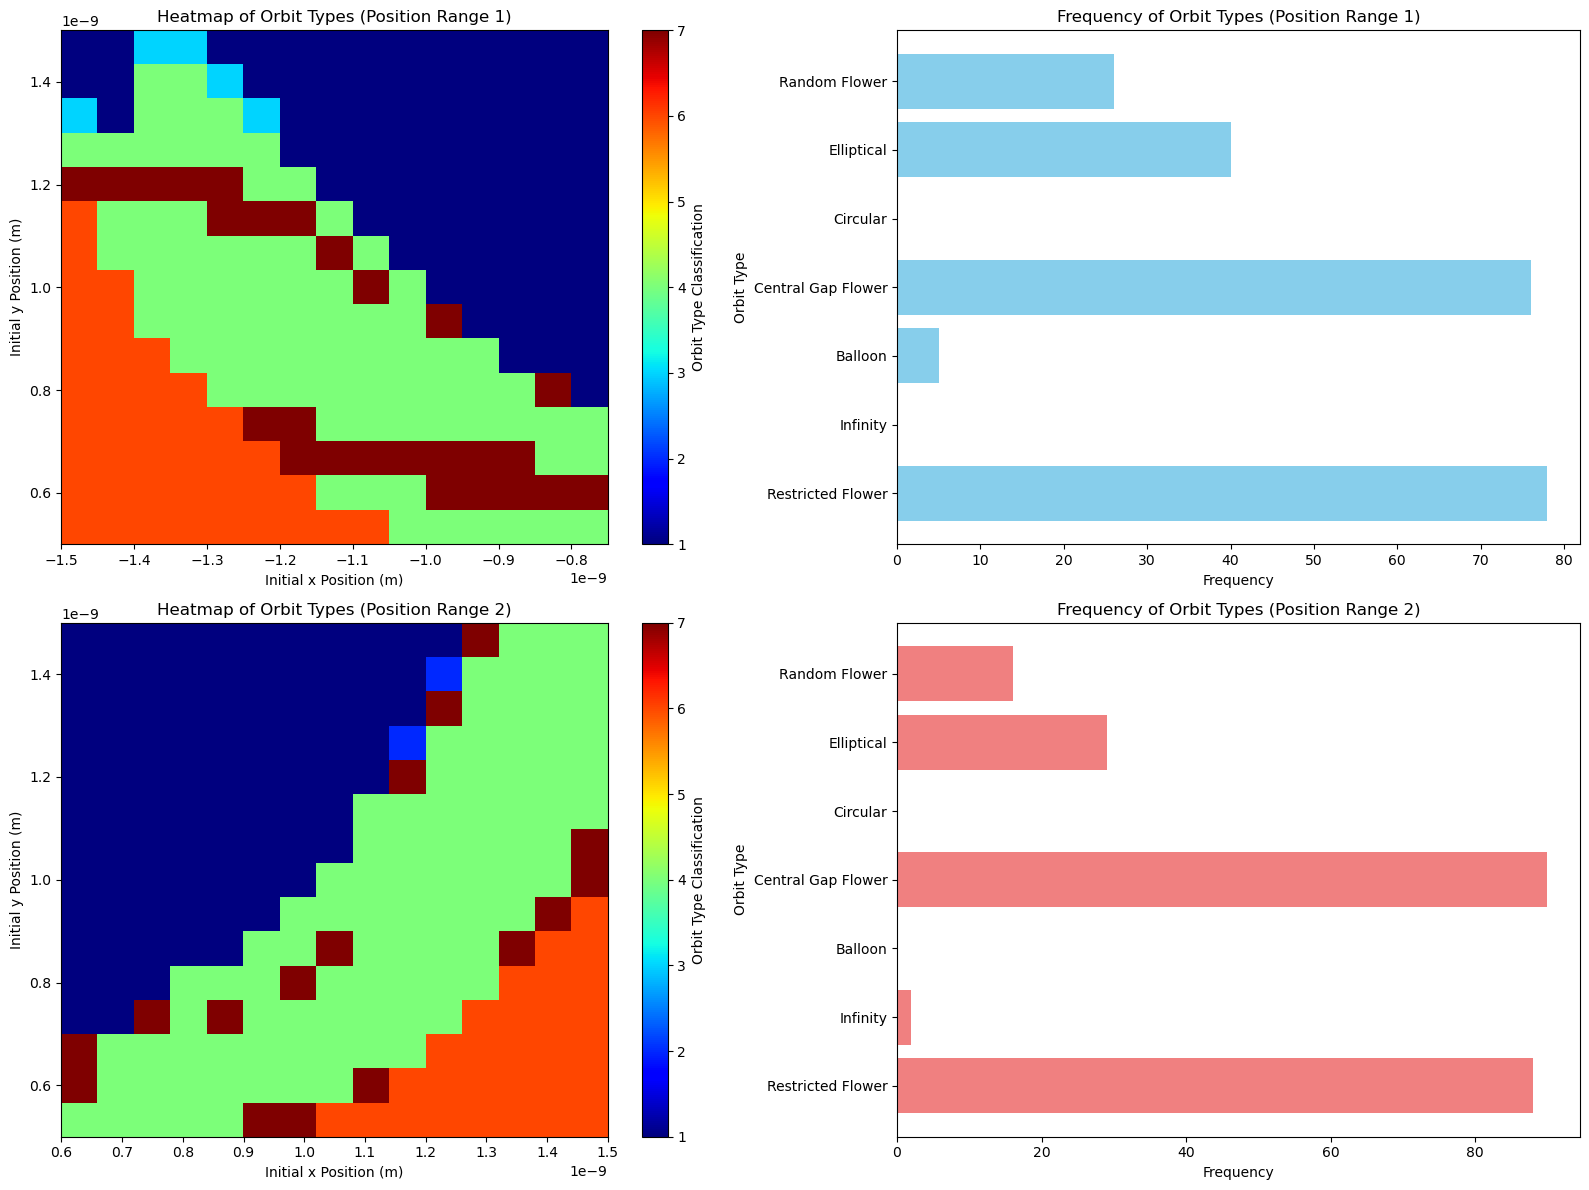

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Define orbit types
orbit_types = [
    "Random Flower",
    "Elliptical",
    "Circular",
    "Central Gap Flower",
    "Balloon",
    "Infinity",
    "Restricted Flower"
]

# Define the range of x and y positions for initial coordinates (1st set)
position_range_x1 = np.linspace(-1.5e-9, -0.75e-9, 15)  # Range for initial x-coordinate
position_range_y1 = np.linspace(0.5e-9, 1.5e-9, 15)  # Range for initial y-coordinate

# Define the range of x and y positions for initial coordinates (2nd set)
position_range_x2 = np.linspace(0.6e-9, 1.5e-9, 15)  # Range for initial x-coordinate
position_range_y2 = np.linspace(0.5e-9, 1.5e-9, 15)  # Range for initial y-coordinate

# Function to generate orbit heatmaps and frequencies
def generate_orbit_data(position_range_x, position_range_y):
    x2d, y2d = np.meshgrid(position_range_x, position_range_y)
    MH = np.zeros((len(position_range_y), len(position_range_x)))

    # Fixed initial velocity
    state0 = [0, 0, 1e5, 0]  # Example initial velocity

    # Run the simulation for each (x, y) combination and classify the orbit
    for i in range(len(position_range_x)):
        for j in range(len(position_range_y)):
            # Set the initial x and y positions
            state0[0] = position_range_x[i]
            state0[1] = position_range_y[j]

            # Run the simulation and classify the orbit
            energy, _, orbit_class = run_sim3(state0)
            MH[j, i] = orbit_class  # Store orbit classification in the 2D grid

    # Calculate orbit frequencies
    orbit_frequencies = np.zeros(len(orbit_types))
    for orbit_class in range(1, len(orbit_types) + 1):
        orbit_frequencies[orbit_class - 1] = np.sum(MH == orbit_class)

    return MH, orbit_frequencies

# Generate data for both position ranges
MH1, orbit_frequencies1 = generate_orbit_data(position_range_x1, position_range_y1)
MH2, orbit_frequencies2 = generate_orbit_data(position_range_x2, position_range_y2)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Heatmap for 1st position range
ax1 = axes[0, 0]
im1 = ax1.imshow(MH1, extent=(position_range_x1[0], position_range_x1[-1], position_range_y1[0], position_range_y1[-1]),
                 cmap='jet', aspect='auto', interpolation='nearest')
fig.colorbar(im1, ax=ax1, label="Orbit Type Classification")
ax1.set_title("Heatmap of Orbit Types (Position Range 1)")
ax1.set_xlabel("Initial x Position (m)")
ax1.set_ylabel("Initial y Position (m)")

# Frequency plot for 1st position range
ax2 = axes[0, 1]
ax2.barh(orbit_types, orbit_frequencies1[::-1], color='skyblue')
ax2.set_title("Frequency of Orbit Types (Position Range 1)")
ax2.set_xlabel("Frequency")
ax2.set_ylabel("Orbit Type")
ax2.invert_yaxis()

# Heatmap for 2nd position range
ax3 = axes[1, 0]
im2 = ax3.imshow(MH2, extent=(position_range_x2[0], position_range_x2[-1], position_range_y2[0], position_range_y2[-1]),
                 cmap='jet', aspect='auto', interpolation='nearest')
fig.colorbar(im2, ax=ax3, label="Orbit Type Classification")
ax3.set_title("Heatmap of Orbit Types (Position Range 2)")
ax3.set_xlabel("Initial x Position (m)")
ax3.set_ylabel("Initial y Position (m)")

# Frequency plot for 2nd position range
ax4 = axes[1, 1]
ax4.barh(orbit_types, orbit_frequencies2[::-1], color='lightcoral')
ax4.set_title("Frequency of Orbit Types (Position Range 2)")
ax4.set_xlabel("Frequency")
ax4.set_ylabel("Orbit Type")
ax4.invert_yaxis()

# Adjust layout and save the figure
plt.tight_layout()
output_file = "orbit_analysis_subplots.png"
plt.savefig(output_file, format="png", dpi=300)
plt.show()

### Analyzing the Position Phase Space: The Instability Strip

**Symmetry**
- Symmetry is still apparent!
- There is clearly intrinsic symmetry in an orbit of the electron in the saturnian model
- The heat map shows a strip of instability dominated by the central gap flower orbit, with the random flower orbit mixed in at the boundaries
- This has implications the that the random flower orbit is also a *transition orbit* for both the central gap and elliptical orbit

**Frequency bar graph**
- The frequency bar graphs are also very similar, further evidencing the symmetry of the system
- In both bar graphs the central gap flower and restricted flower orbits are the most frequent, followed by elliptical orbits, then random flower, then infinity orbit.

**Investigating further**
- The symmetry of the system, however, may be limited to lower velocities
- Since in the top left plot, the electrons are moving towards the nuclei, and in the top right plot, they are moving away, they may appear to be symmetric because the speed of the electron is on the lower end
- If we increase this velocity, we can re-examine this region and see if any changes are present:
- We will increase the velocity to a constant velocity of $ 5 \times 10^5$, significantly higher than the previous velocity of $ 1 \times 10^5 $, which should give a good indication for any changes that should be present due to this change:

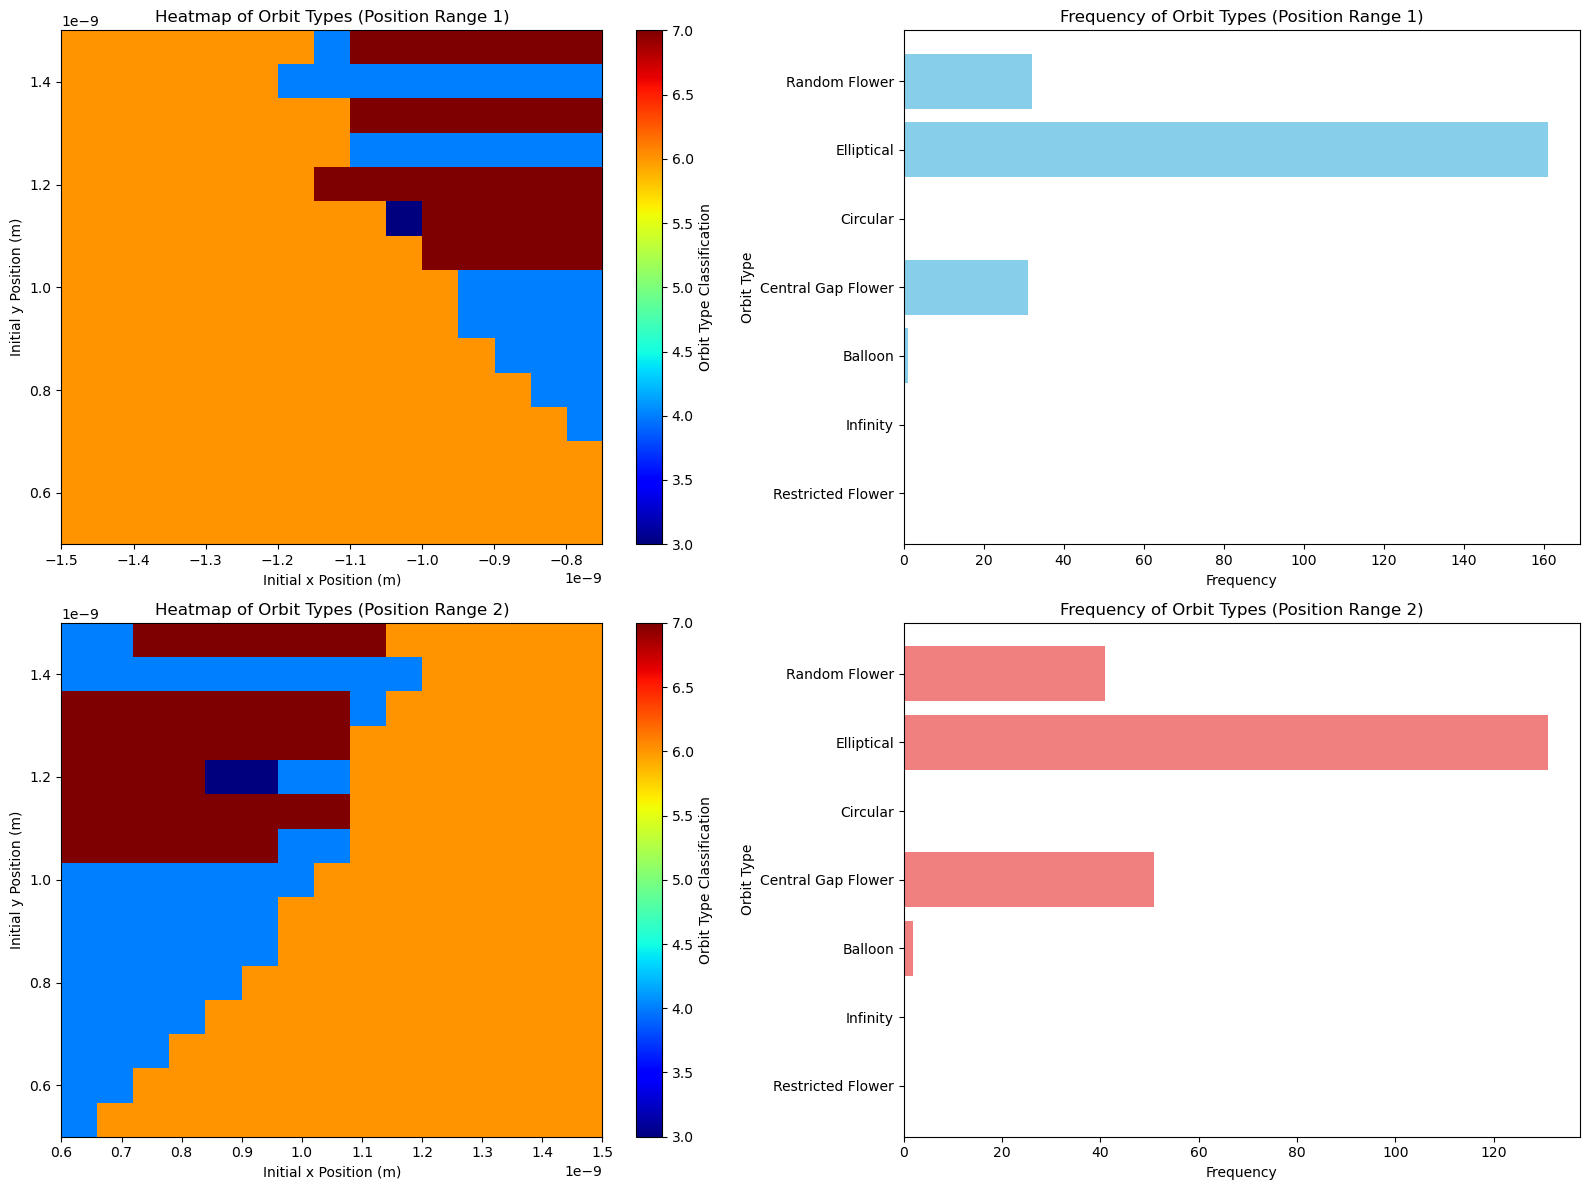

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Define orbit types
orbit_types = [
    "Random Flower",
    "Elliptical",
    "Circular",
    "Central Gap Flower",
    "Balloon",
    "Infinity",
    "Restricted Flower"
]

# Define the range of x and y positions for initial coordinates (1st set)
position_range_x1 = np.linspace(-1.5e-9, -0.75e-9, 15)  # Range for initial x-coordinate
position_range_y1 = np.linspace(0.5e-9, 1.5e-9, 15)  # Range for initial y-coordinate

# Define the range of x and y positions for initial coordinates (2nd set)
position_range_x2 = np.linspace(0.6e-9, 1.5e-9, 15)  # Range for initial x-coordinate
position_range_y2 = np.linspace(0.5e-9, 1.5e-9, 15)  # Range for initial y-coordinate

# Function to generate orbit heatmaps and frequencies
def generate_orbit_data(position_range_x, position_range_y):
    x2d, y2d = np.meshgrid(position_range_x, position_range_y)
    MH = np.zeros((len(position_range_y), len(position_range_x)))

    # Fixed initial velocity
    state0 = [0, 0, 5e5, 0]  

    # Run the simulation for each (x, y) combination and classify the orbit
    for i in range(len(position_range_x)):
        for j in range(len(position_range_y)):
            # Set the initial x and y positions
            state0[0] = position_range_x[i]
            state0[1] = position_range_y[j]

            # Run the simulation and classify the orbit
            energy, _, orbit_class = run_sim3(state0)
            MH[j, i] = orbit_class  # Store orbit classification in the 2D grid

    # Calculate orbit frequencies
    orbit_frequencies = np.zeros(len(orbit_types))
    for orbit_class in range(1, len(orbit_types) + 1):
        orbit_frequencies[orbit_class - 1] = np.sum(MH == orbit_class)

    return MH, orbit_frequencies

# Generate data for both position ranges
MH1, orbit_frequencies1 = generate_orbit_data(position_range_x1, position_range_y1)
MH2, orbit_frequencies2 = generate_orbit_data(position_range_x2, position_range_y2)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Heatmap for 1st position range
ax1 = axes[0, 0]
im1 = ax1.imshow(MH1, extent=(position_range_x1[0], position_range_x1[-1], position_range_y1[0], position_range_y1[-1]),
                 cmap='jet', aspect='auto', interpolation='nearest')
fig.colorbar(im1, ax=ax1, label="Orbit Type Classification")
ax1.set_title("Heatmap of Orbit Types (Position Range 1)")
ax1.set_xlabel("Initial x Position (m)")
ax1.set_ylabel("Initial y Position (m)")

# Frequency plot for 1st position range
ax2 = axes[0, 1]
ax2.barh(orbit_types, orbit_frequencies1[::-1], color='skyblue')
ax2.set_title("Frequency of Orbit Types (Position Range 1)")
ax2.set_xlabel("Frequency")
ax2.set_ylabel("Orbit Type")
ax2.invert_yaxis()

# Heatmap for 2nd position range
ax3 = axes[1, 0]
im2 = ax3.imshow(MH2, extent=(position_range_x2[0], position_range_x2[-1], position_range_y2[0], position_range_y2[-1]),
                 cmap='jet', aspect='auto', interpolation='nearest')
fig.colorbar(im2, ax=ax3, label="Orbit Type Classification")
ax3.set_title("Heatmap of Orbit Types (Position Range 2)")
ax3.set_xlabel("Initial x Position (m)")
ax3.set_ylabel("Initial y Position (m)")

# Frequency plot for 2nd position range
ax4 = axes[1, 1]
ax4.barh(orbit_types, orbit_frequencies2[::-1], color='lightcoral')
ax4.set_title("Frequency of Orbit Types (Position Range 2)")
ax4.set_xlabel("Frequency")
ax4.set_ylabel("Orbit Type")
ax4.invert_yaxis()

# Adjust layout and save the figure
plt.tight_layout()
output_file = "orbit_analysis_subplots.png"
plt.savefig(output_file, format="png", dpi=300)
plt.show()

### Analysis:

The results of this heat map and frequency of orbits make it clear: **Symmetry is an intrinsic property in the Saturnian model of an electron orbiting a system of nuclei**

**Heatmaps**
- Even after increasing the velocity substantially, the symmetry of the system remains
- The heat map does change in its appearance, yes, but this is as expected because we have already discussed how orbits change with velocity, specficially shifting to more elliptical heavy orbits as predicted
- What is interesting, is that the same transitions exist in the exact same regions, with exactly opposite coordinates
- There is this orange staircase (elliptical orbits) that transitions into a blue region (central gap flower), with transition orbits of random flower present in various regions of the plot

**Frequency Plot**
- The frequency plot provides more evidence to this symmetry, as the orbits have shifted similarly to a new distribution of orbits.
- Elliptical orbits dominate, being the most apparent at the higher velocities, as expected, with the random flower and central gap being the next most frequent.

### Analyzing the Position Phase Space: The Center of the Position phase space
- To confirm this result of the intrinsic presence of symmetry in the Saturnian Model, we will focus on the center of the position phase space where there are several orbits present
- In the phase space of iterating position we saw the precense of circular, infinity, random flower, restricted flower orbits
- By zooming into this area of the plot and plotting the results of a lower velocity vs a higher velocity, we will be able to see any differences, or similarities in the symmetry of the orbits
- This will also provide evidence of the types or orbits present where *more initial force* is present, as the electron starts much closer to the nuclei

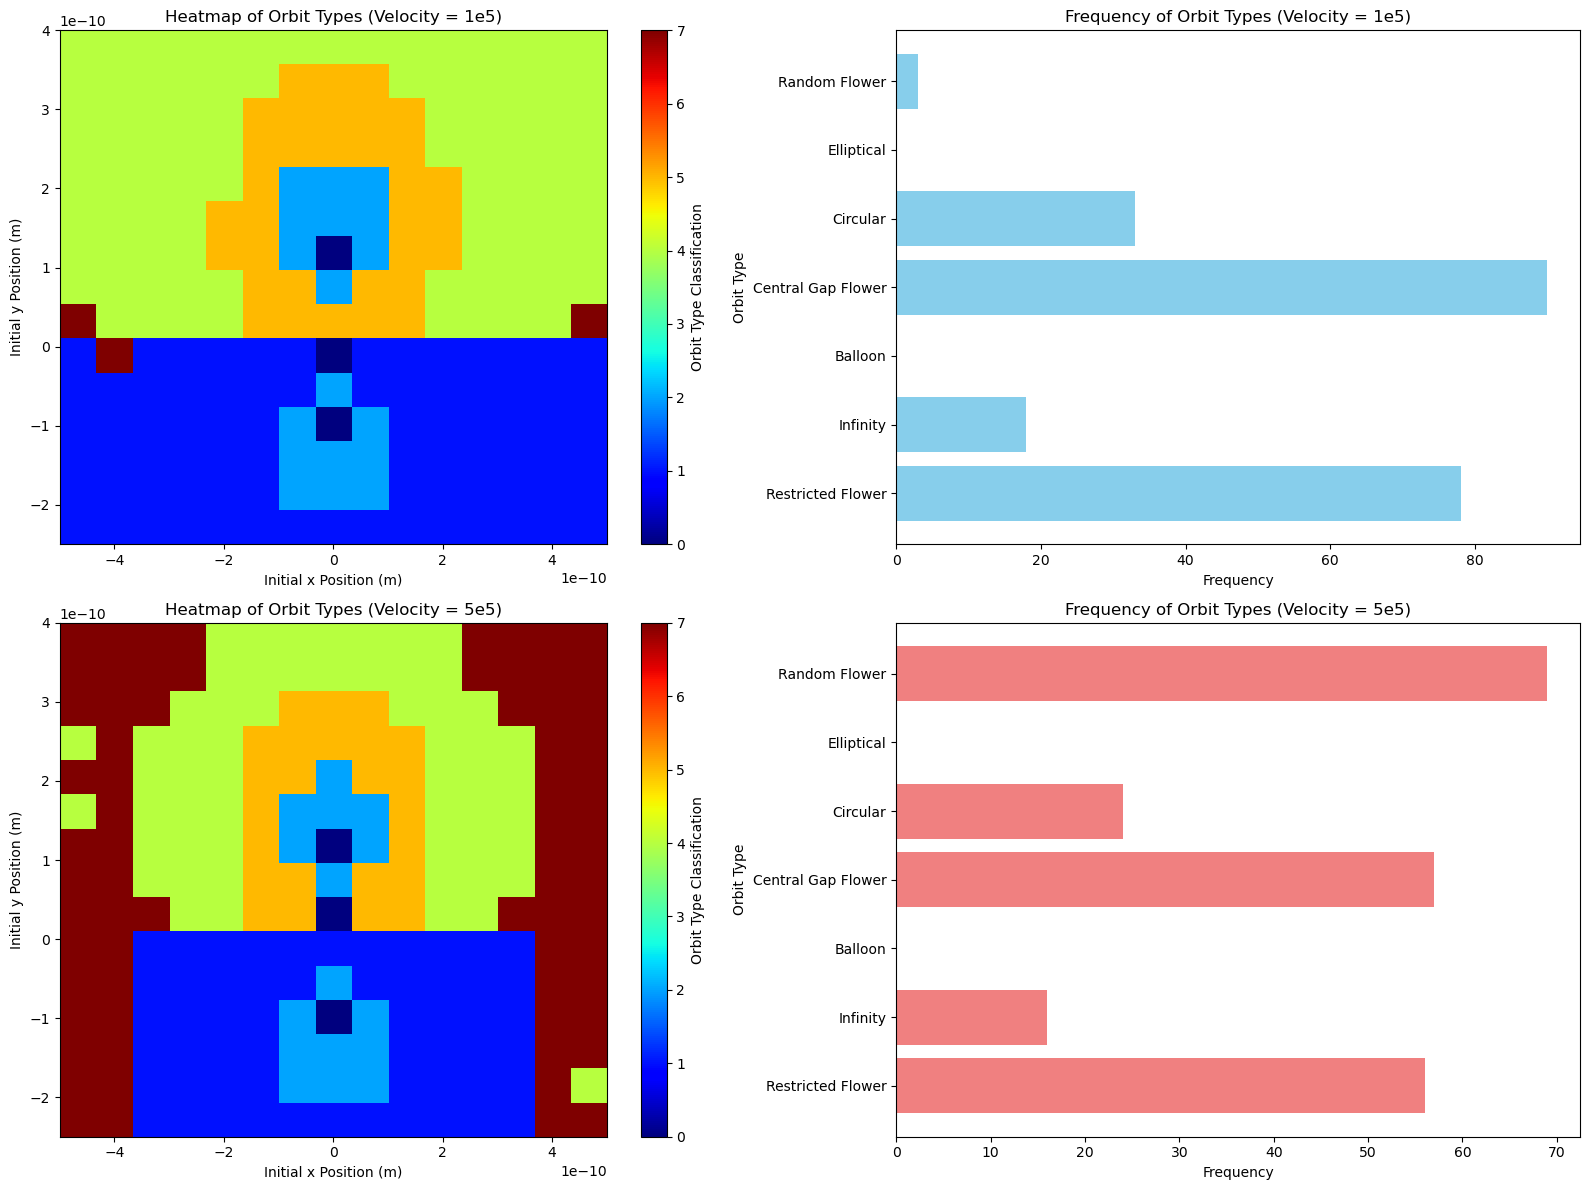

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Define orbit types
orbit_types = [
    "Random Flower",
    "Elliptical",
    "Circular",
    "Central Gap Flower",
    "Balloon",
    "Infinity",
    "Restricted Flower"
]

# Define the range of x and y positions for initial coordinates
position_range_x = np.linspace(-0.5e-9, 0.5e-9, 15)  # Range for initial x-coordinate
position_range_y = np.linspace(-0.25e-9, 0.4e-9, 15)  # Range for initial y-coordinate

# Discrete velocities
velocities = [1e5, 5e5]  # Discrete velocities to test

# Function to generate orbit heatmaps and frequencies
def generate_orbit_data(position_range_x, position_range_y, velocity):
    x2d, y2d = np.meshgrid(position_range_x, position_range_y)
    MH = np.zeros((len(position_range_y), len(position_range_x)))

    # Run the simulation for each (x, y) combination and classify the orbit
    for i in range(len(position_range_x)):
        for j in range(len(position_range_y)):
            state0 = [position_range_x[i], position_range_y[j], velocity, 0]
            try:
                energy, _, orbit_class = run_sim3(state0)
                MH[j, i] = orbit_class  # Store orbit classification in the 2D grid
            except Exception:
                continue  # Silently skip problematic cases

    # Calculate orbit frequencies
    orbit_frequencies = np.zeros(len(orbit_types))
    for orbit_class in range(1, len(orbit_types) + 1):
        orbit_frequencies[orbit_class - 1] = np.sum(MH == orbit_class)

    return MH, orbit_frequencies

# Generate data for both velocities
data_1e5 = generate_orbit_data(position_range_x, position_range_y, velocities[0])
data_5e5 = generate_orbit_data(position_range_x, position_range_y, velocities[1])

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot for 1e5 velocity
MH1, orbit_frequencies1 = data_1e5
ax1 = axes[0, 0]
im1 = ax1.imshow(MH1, extent=(position_range_x[0], position_range_x[-1], position_range_y[0], position_range_y[-1]),
                 cmap='jet', aspect='auto', interpolation='nearest')
fig.colorbar(im1, ax=ax1, label="Orbit Type Classification")
ax1.set_title("Heatmap of Orbit Types (Velocity = 1e5)")
ax1.set_xlabel("Initial x Position (m)")
ax1.set_ylabel("Initial y Position (m)")

ax2 = axes[0, 1]
ax2.barh(orbit_types, orbit_frequencies1[::-1], color='skyblue')
ax2.set_title("Frequency of Orbit Types (Velocity = 1e5)")
ax2.set_xlabel("Frequency")
ax2.set_ylabel("Orbit Type")
ax2.invert_yaxis()

# Plot for 5e5 velocity
MH2, orbit_frequencies2 = data_5e5
ax3 = axes[1, 0]
im2 = ax3.imshow(MH2, extent=(position_range_x[0], position_range_x[-1], position_range_y[0], position_range_y[-1]),
                 cmap='jet', aspect='auto', interpolation='nearest')
fig.colorbar(im2, ax=ax3, label="Orbit Type Classification")
ax3.set_title("Heatmap of Orbit Types (Velocity = 5e5)")
ax3.set_xlabel("Initial x Position (m)")
ax3.set_ylabel("Initial y Position (m)")

ax4 = axes[1, 1]
ax4.barh(orbit_types, orbit_frequencies2[::-1], color='lightcoral')
ax4.set_title("Frequency of Orbit Types (Velocity = 5e5)")
ax4.set_xlabel("Frequency")
ax4.set_ylabel("Orbit Type")
ax4.invert_yaxis()

# Adjust layout and save the figure
plt.tight_layout()
output_file = "orbit_analysis_two_velocities.png"
plt.savefig(output_file, format="png", dpi=300)
plt.show()


#### Analysis:

**Heat Maps**
- The central structures of both phase space iterations show many similarities
- There is a clear envelope of circular orbits (yellow) surrounding infinity orbits in both plots (light blue)
- Restricted flower orbits (dark blue) are present in both plots in the lower half of the heat map, and central gap flower orbits at the top portion of the heat maps
- There does appear to be a lot more random flower orbits in the bottom plots as we increase velocity, which take over some of the central gap orbits

**Frequency Histograms**
- The frequency historgrams reveal the same general trends of orbits, with the caviat that the random flower orbit is introduced way more within the higher velocity phase space
- Central gap flower and restricted flower orbits are on the higher end of frequency in both heat map plots, with circular and infinity being the two lowest

**Symmetry**
- Although the random flower orbit is introduced in the higher velocity heat map, which differs from the lower velocity heat map, the main structures and intricusies remain in both heat maps
- The main structure of the circular orbit enveloping the infinity orbits are present in both heat maps, the bottom half of both heat maps are similar with essentially the same infinity orbit structure (light blue) within the restricted flower (dark blue) area
- **This refines our hypothesis that symmetry is an intrinsic aspect of a system of an electron orbiting two nuclei**
- **It is clear, no matter where in the orbit we are, and what velocity we start at, central symmetric structures are always similaryl present**

**More Takeaways**
- Infinity orbits, which have a low frequency in a larger phase space where we previously iterating position over a larger region, is most frequenct near the center of the plot, where they experience more initial force from the two nuclei
- This result can be attributed to the idea that the electrons must perfectly move through the center of the two nuclei, and thus will be more present when it starts closer to the two
- Additionally, there seems to be an increase in random flower orbits as we increase velocity
- This result was also present in the previous phase space iteration, where we looked at the instability strip. As we increased the velocity, the random flower orbit increased
- This can be attributed to a randomness of orbit as we inrease veloccity. There is less predictability as we increase velocity, because thee is less assurance how the nuclei will act on the electrons when the electrons more dominate the system

## Key Takeaways:

**Symmetry in the Saturnian Model**

Across all phase-space analyses, symmetry in orbital paths is consistently observed. For every orbit on one side of the system, a corresponding symmetric orbit exists on the opposite side. This symmetry persists even at higher velocities or when varying positions, indicating that the forces from the two nuclei create a balanced, intrinsic structure within the model. The symmetry confirms the consistency of the governing physics, reinforcing that the system's behavior is dictated by the interaction of equal and opposing forces.

**Dominance of Specific Orbit Types**

Orbits such as "Central Gap Flower," "Restricted Flower," and "Circular" are the most frequently observed across all phase spaces. These orbits are more stable because they require fewer specific conditions to form. Their broad ranges of allowable initial velocity and position make them dominant outcomes in the system. Contrastingly, less frequent orbits like "Balloon" and "Infinity" require stricter initial conditions, such as finely tuned starting velocities or positions, reflecting their fragility and dependence on precise events for classification.


**Velocity Dependence of Orbits**

Heatmaps and frequency plots show that certain orbit types, such as "Elliptical," increase in prevalence with higher velocities due to their dependence on greater eccentricity. Chaotic orbits like "Random Flower" also become more common at higher velocities, where the electron’s motion begins to dominate over the nuclei's attractive forces, leading to unpredictable trajectories. "Circular" orbits, while more stable, also emerge at specific higher velocities when the electron’s centripetal force precisely balances the nuclei's attraction.

**Position Dependence of Orbits**

Orbits originating closer to the nuclei tend to be more stable and symmetric, favoring "Circular" or "Infinity" types due to the strong central forces dominating the dynamics.
As the initial position of the electron moves farther from the nuclei, orbits such as "Elliptical" or "Random Flower" become more prevalent, reflecting reduced  influence and greater sensitivity to velocity perturbations. Heatmaps confirm that the system's stability decreases with increasing distance from the nuclei, with chaotic orbits emerging at outer regions of the phase space.

**Energy and Stability Thresholds**

Energy plots reveal exponential growth in energy with increasing velocity, consistent with the relationship $ KE \alpha v^2 $. Stable orbits are confined to specific energy thresholds, with positive energy signifying an unbound electron escaping the nuclei’s attraction. The exponential energy growth and velocity dependence reinforce that stability is tightly linked to the balance between the electron's kinetic energy and the attractive potential energy of the nuclei.

### Overall Insights:

The Saturnian model displays a delicate balance between symmetry, stability, and chaos, driven by initial conditions. Symmetry underpins the consistency of the system, while transitions and chaotic regions highlight the boundaries of stability. Orbits like "Circular" and "Central Gap Flower" dominate due to their broadly defined stability range, while infinity and balloon orbits require intricate conditions, reflecting their intrinsic fragility. Velocity and position both play interconnected roles, emphasizing the need to consider both parameters when classifying orbits and understanding the system’s dynamics.

## Appendix 1.2 - Project Validation

There were two ways in which I validated the behaviour of the simulation
1. The first way of validation was running the initial energy calculations of the system to confirm the simulation was properly calculating the energy of the simulation based off the simulation, as this gives important insight into where the boundary between stable and unstable orbits occur:
2. The second way was validating consecutive iterations of solve_ivp. Through doing the hand calculations of what solve_ivp does effortlessly, and getting the same results, we know the code is correctly updating the orbit of the electron at a given time and thus we can trust the results it gives us

#### Verification 1:

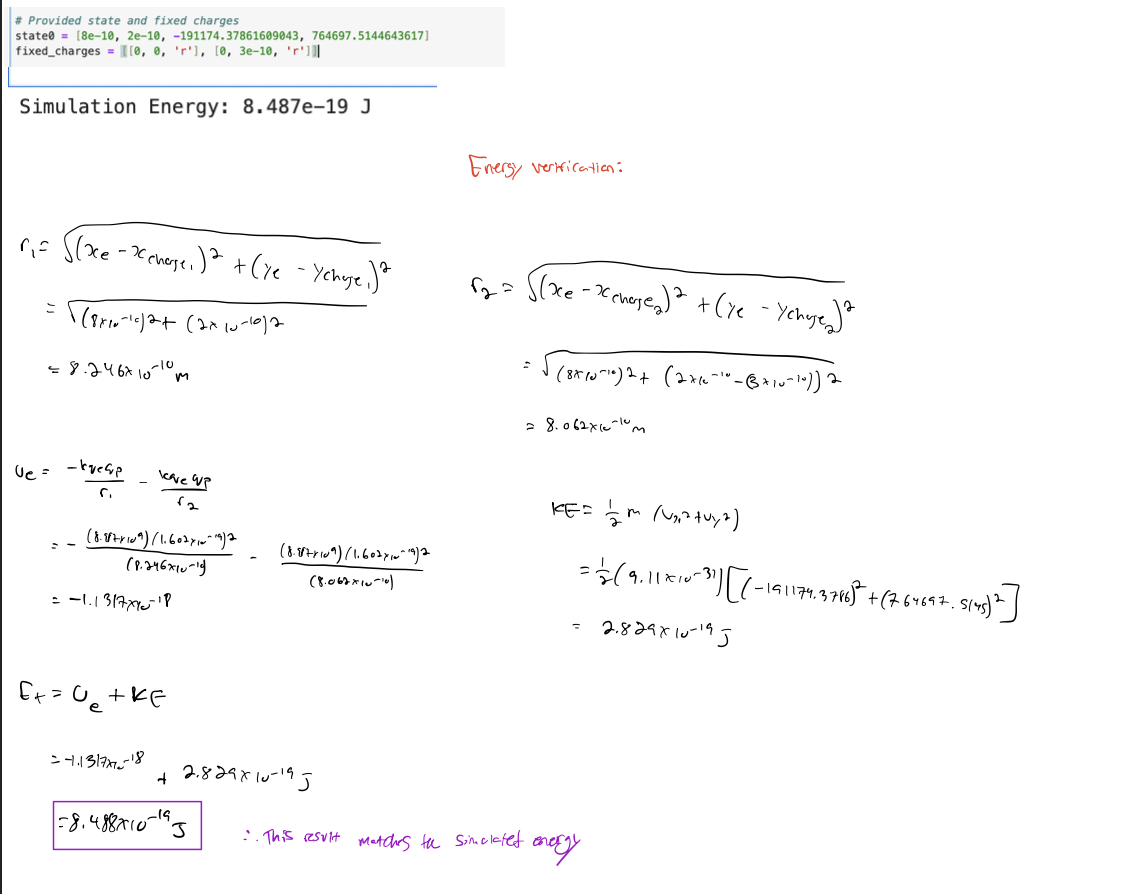

#### Verification 2:

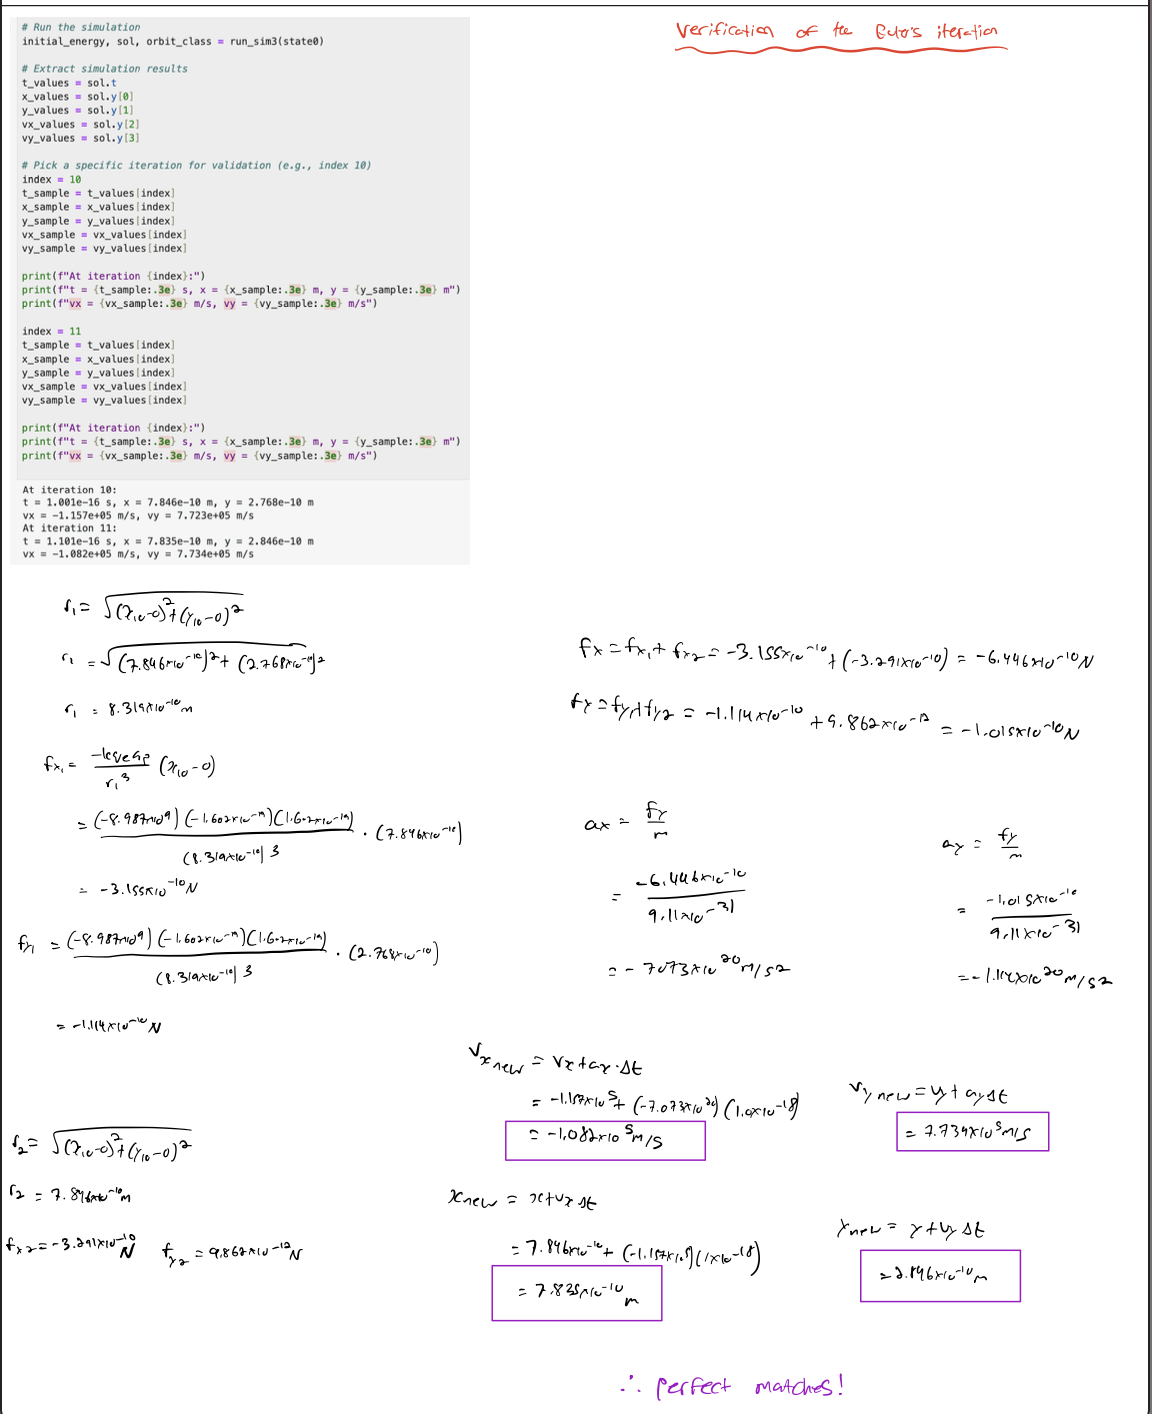

## Appendix 1.2 - Reflection Questions

#### Reflection 1: Coding Approaches (A)

In this project, I applied structured and methodical coding techniques to model stable orbits in the Saturnian atomic model. The primary challenge was to balance the realism of the physical model with computational efficiency, as there are a lot of assumptions that have to be made. I heavily relied on the solve_ivp function to simulate euler’s method to model the equations of motion for the multi-particle system. A key focus was developing functions that could easily adapt to changes in initial conditions, such as electron velocities and positions. This allowed me to iterate quickly over phase-space parameters and identify regions of stability and instability.
One significant extension of my coding knowledge was implementing orbit classification functions. These functions analyzed the trajectory data to identify orbit types, such as elliptical orbits, infinity orbits, and central gap orbits. By tracking the electron's position and using several events which had to be true or not true, I gained insight into how orbit transitions occurred.

The most unforeseen challenge was the small scale I was working on and the run-time needed to execute the codes. The small scale required a very high rtol, but even so, using solve_ivp with such small units introduced problems in the code. This created challenges in defining events for different types of orbits, and simulating the total orbital path of the electron in the system. Additionally,  the run-time needed to execute the code created a complication in the code I wrote. I needed to make sure the code was perfect before doing a large iteration because of the significant time scale it takes to run it.

#### Reflection 2: Coding Approaches (B)

One aspect of the code I am particularly proud of is the phase space analysis plots and graphs that I needed to continuously produce throughout the investigation. They were not all pretty, but they were super effective in portraying the results of the iterations of states, and presented the data clearly. These were generally complicated to code, as they involved grabbing many aspects of previous code in addition to implementing new ones.

However, an area that could use further effort is computational efficiency. Some of the simulations, particularly those with fine-grained parameter sweeps, were computationally expensive. While it is hard to avoid these nested for loops which cause a much longer run-time, there were surely ways in which I could have optimized my code, and thus reduce the run-time. Additionally, it’s possible I could have optimized my event detection code to be tailored to more general cases, and thus not need as many events attempting to detect things at all times, causing a significantly higher run-time too.

#### Reflection 3: Simulation Physics and Investigation (A)

This project significantly deepened my understanding of orbital mechanics in multi-particle systems. Translating the forces between particles into code required careful attention to coloumb forces throughout the iterations of solve_ivp. Through repeated testing and refinement, I developed a robust model that could handle the complexities of two fixed nuclei and a single orbiting electron. This code would display the orbits fully and give me a better understanding of the conditions which govern an electron’s motion. Additionally I had to do a lot of research into the Saturnian model and its implications. I needed to understand what models hadn’t been predicted yet, and thus what assumptions needed to be made. For example, we had to make the assumption that the electron does not radiate energy, which was predicted classically at the time.

The phase-space investigation was thorough, focusing on regions where stable orbits transition to unstable ones, and looking at the conditions that influence a certain type of orbit. By iterating over initial velocities and positions, I identified "transition regions" where small changes in parameters led to drastic changes in orbit types. For example, increasing the electron's velocity beyond a threshold caused transitions from circular orbits to elliptical orbits, highlighting the boundaries of orbits.
A key takeaway was the realization that symmetry plays a critical role in the types of orbits in a system of an electron and two nuclei. For instance, the symmetry of the two nuclei creates regions of stability where forces balance out, allowing periodic orbits to form. Even after increasing the velocity and having the expectations of losing symmetry, the phase space investigation provided interesting results that symmetry is an intrinsic part of this system.

#### Reflection 4: Simulation Physics and Investigation (B)

One highlight of my simulation was the ability to visualize the various orbit types in any given system. While I only did one electron and two nuclei, the code allows for easy iterating into different initial conditions, which makes the code very versatile and useful. Additionally, by plotting the electron's trajectory, I could clearly see when it transitioned from one orbit to another, and also when it transitioned from stable to unstable. This visualization provided compelling evidence for the thresholds I identified in the phase-space analysis.

However, an area that could benefit from further effort is exploring more complex multi-particle systems, such as two electrons orbiting a system of two nuclei. This would help generalize when certain types of orbits will appear in any given system, not just the singular system that I focused on. Furthermore, exploring other physical parameters, such as varying the charges of the nuclei or adding external electric fields, would make the investigation more comprehensive.

#### Reflection 5: Effectiveness of Communication

A key strength of my communication was the use of clear, annotated visualizations to explain the results of the simulation. For example, multi-panel heatmaps of initial velocity versus orbit type effectively summarized the stability regions in phase space. Histograms of orbit frequencies provided a statistical overview of which orbits were most common under varying conditions. Orbital trajectories provides the fundamental distinction between orbits which was the basis of the entire investigation

Perhaps incorporating more comparative analyses, such as how results change with varying nucleus separations, would provide additional context for interpreting the findings. Altering this aspect, or perhaps the number of particles in the system could further generalize the results of when different orbits occur.
